---
# 📊 Complete EDA — Organ Transplant **Donor** Dataset
> 800 Donors · 68+ Features · Pakistan Healthcare Data

| Section | Plots |
|---------|-------|
| Univariate | Histograms, KDE, Boxplots, Countplots, % bars |
| Bivariate | Correlation heatmap, Scatter, Pairplot, Grouped boxes |
| Multivariate | Full heatmap, Violin, Grouped bars |
| Advanced | Cause-of-death breakdown, KDE overlays, Feature analysis, Dashboard |

---

## ⚙️ Setup — Imports & Style

In [1]:
%matplotlib inline
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F8F9FA",
    "axes.edgecolor"   : "#CCCCCC",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.titlepad"    : 10,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "legend.fontsize"  : 9,
    "legend.framealpha": 0.85,
    "grid.color"       : "#E5E5E5",
    "grid.linewidth"   : 0.6,
})

C_BLUE   = "#2C6FAC"
C_RED    = "#D94F3D"
C_GREEN  = "#3A9E5F"
C_ORANGE = "#E5843A"
C_TEAL   = "#2B9EB3"
GENDER_PALETTE = {"Male": C_BLUE, "Female": C_ORANGE}
print("✔ Imports & style configured")

✔ Imports & style configured


## 📂 Data Loading & Column Detection

In [3]:
df = pd.read_excel(r"E:\final datset of opal ai\dataset\donor_preprocessed_FINAL.xlsx", sheet_name="Preprocessed_Data")
print(f"Shape  : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing: {df.isnull().sum().sum()} values")

all_num   = df.select_dtypes(include=np.number).columns.tolist()
bin_cols  = [c for c in all_num if df[c].nunique() == 2]
cont_cols = [c for c in all_num if c not in bin_cols]

ORGAN_COLS = [c for c in df.columns if c in ["Blood","Bone Marrow","Cornea","Heart","Kidney","Liver","Lung","Pancreas","Plasma","Platelet","Skin"]]
BLOOD_COLS = [c for c in df.columns if c.startswith("blood_")]
CITY_COLS  = [c for c in df.columns if c.startswith("City_")]
COND_COLS  = [c for c in df.columns if c.startswith("Condition_")]
CAUSE_COLS = [c for c in df.columns if c.startswith("Cause_")]
CORE_CONT  = ["age","death_hour","death_day","death_month","harvest_time_hours","hospital_encoded"]
CORE_CONT  = [c for c in CORE_CONT if c in df.columns]

def label(col):
    return col.replace("_"," ").replace("blood ","").replace("City ","").replace("Condition ","").replace("Cause ","").title()

print(f"\nContinuous cols : {CORE_CONT}")
print(f"Organ cols      : {ORGAN_COLS}")
print(f"Binary/OHE cols : {len(bin_cols)}")
df.head(3)

Shape  : 800 rows x 73 columns
Missing: 0 values

Continuous cols : ['age', 'death_hour', 'death_day', 'death_month', 'harvest_time_hours', 'hospital_encoded']
Organ cols      : ['Blood', 'Bone Marrow', 'Cornea', 'Heart', 'Kidney', 'Liver', 'Lung', 'Pancreas', 'Plasma', 'Platelet', 'Skin']
Binary/OHE cols : 66


,age,hepatitis_status,alive/deceased,death_hour,death_day,death_month,harvest_time_hours,gender_Male,blood_A+,blood_A-,...,City_Mardan,City_Mirpur AK,City_Multan,City_Okara,City_Peshawar,City_Quetta,City_Rawalpindi,City_Sahiwal,City_Sargodha,City_Sialkot
0,42,0,0,14,0,1,2.25,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,35,0,0,9,3,1,2.25,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28,0,0,22,5,1,2.50,1,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## 📈 Section 1 — Univariate Analysis

### 1.1 Histograms + KDE — Continuous Features

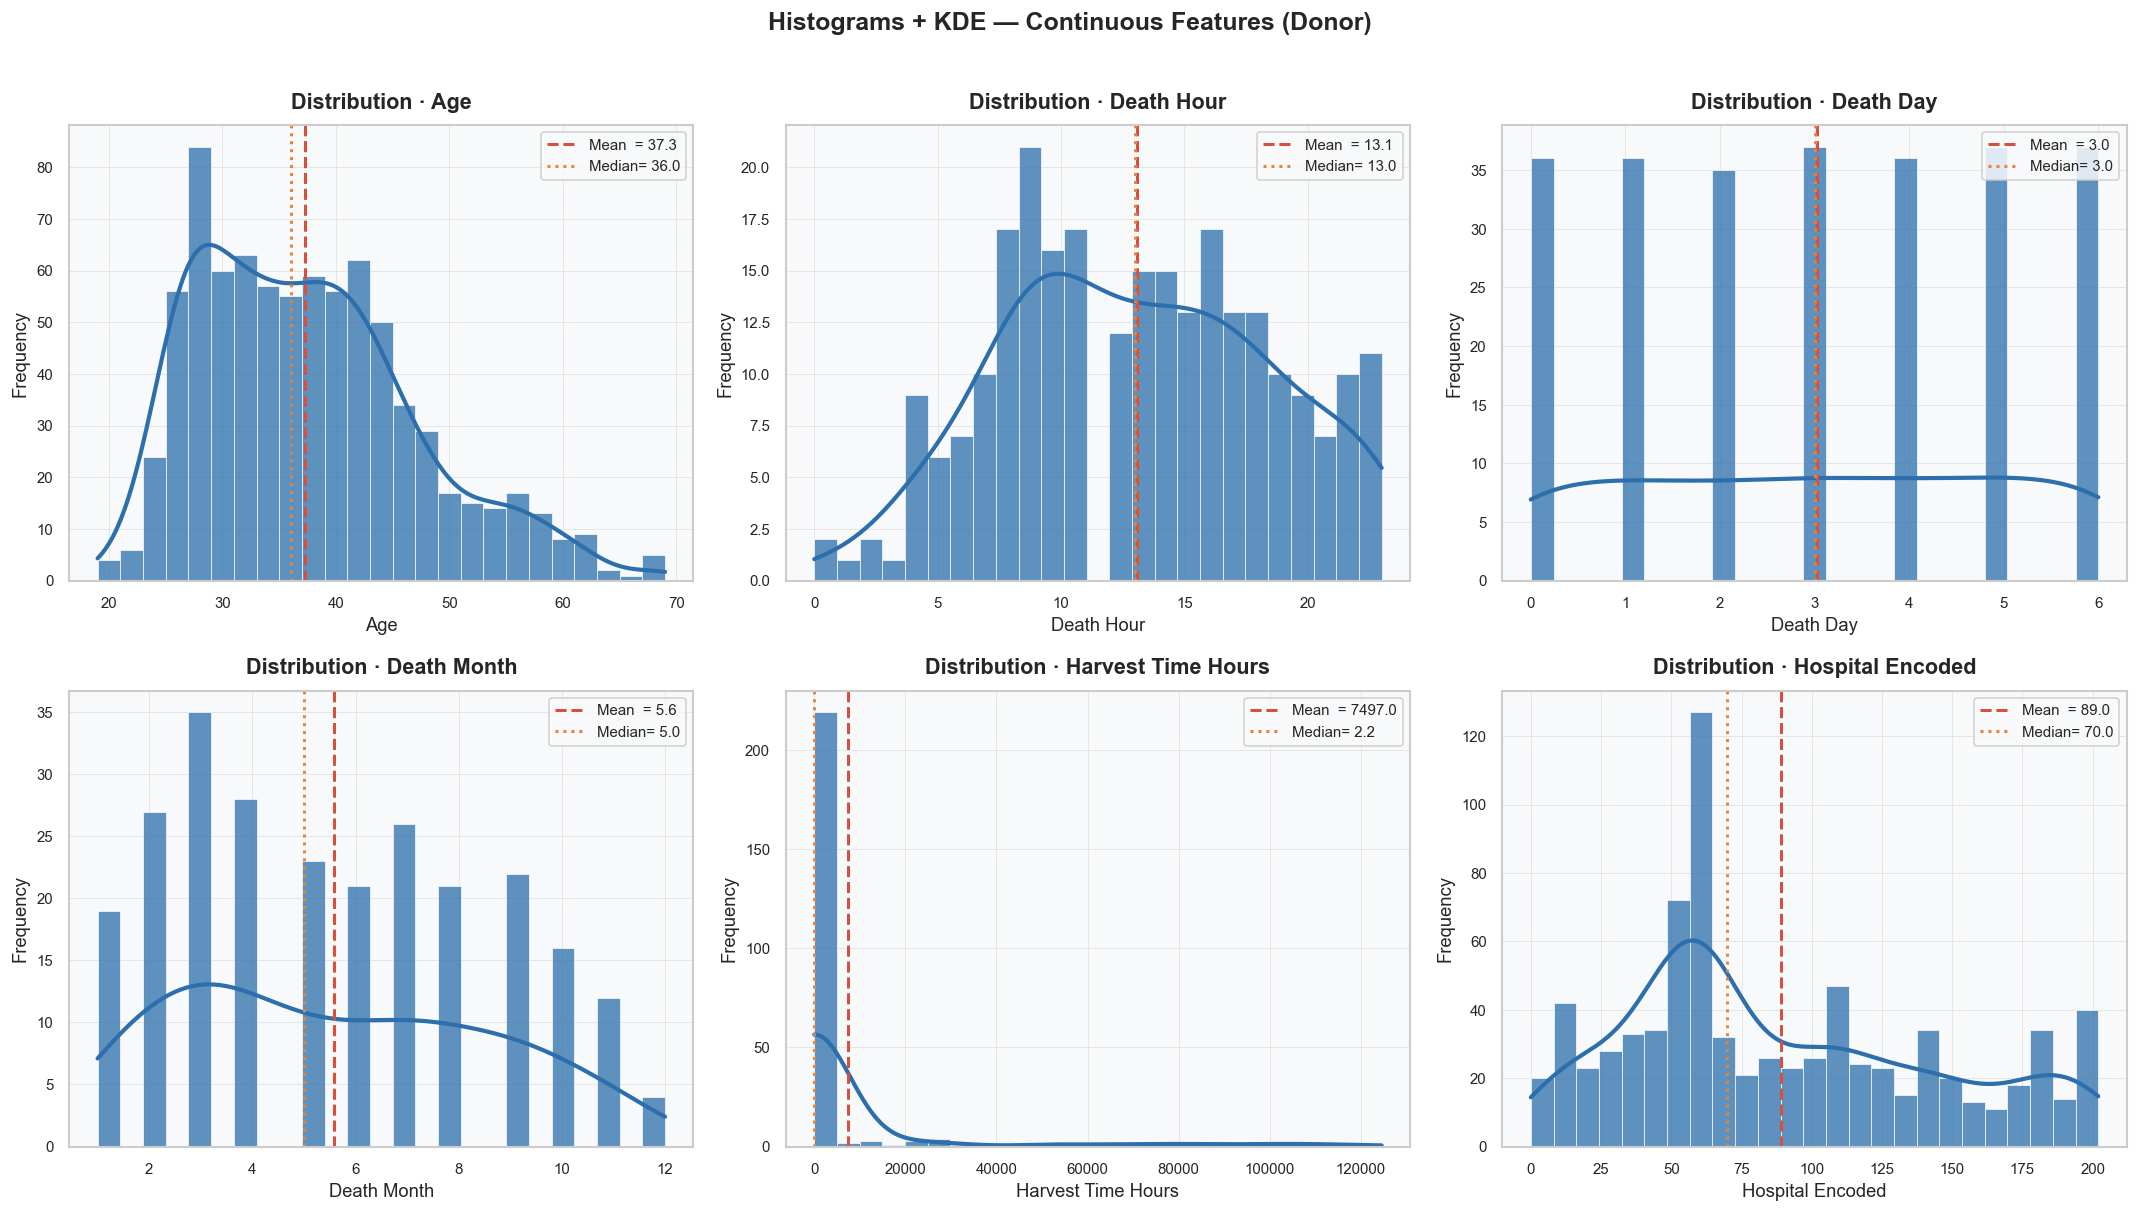

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(CORE_CONT[:6]):
    ax = axes[i]
    valid = df[col][df[col] >= 0]
    mean_v, med_v = valid.mean(), valid.median()
    sns.histplot(valid, kde=True, ax=ax, color=C_BLUE,
                 bins=25, edgecolor="white", linewidth=0.4, alpha=0.75,
                 line_kws={"linewidth": 2.5, "color": C_TEAL})
    ax.axvline(mean_v,  color=C_RED,    linestyle="--", lw=1.8, label=f"Mean  = {mean_v:.1f}")
    ax.axvline(med_v,   color=C_ORANGE, linestyle=":",  lw=1.8, label=f"Median= {med_v:.1f}")
    ax.set_title(f"Distribution · {label(col)}")
    ax.set_xlabel(label(col)); ax.set_ylabel("Frequency")
    ax.legend()
fig.suptitle("Histograms + KDE — Continuous Features (Donor)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 1.2 Boxplots — Outlier Detection

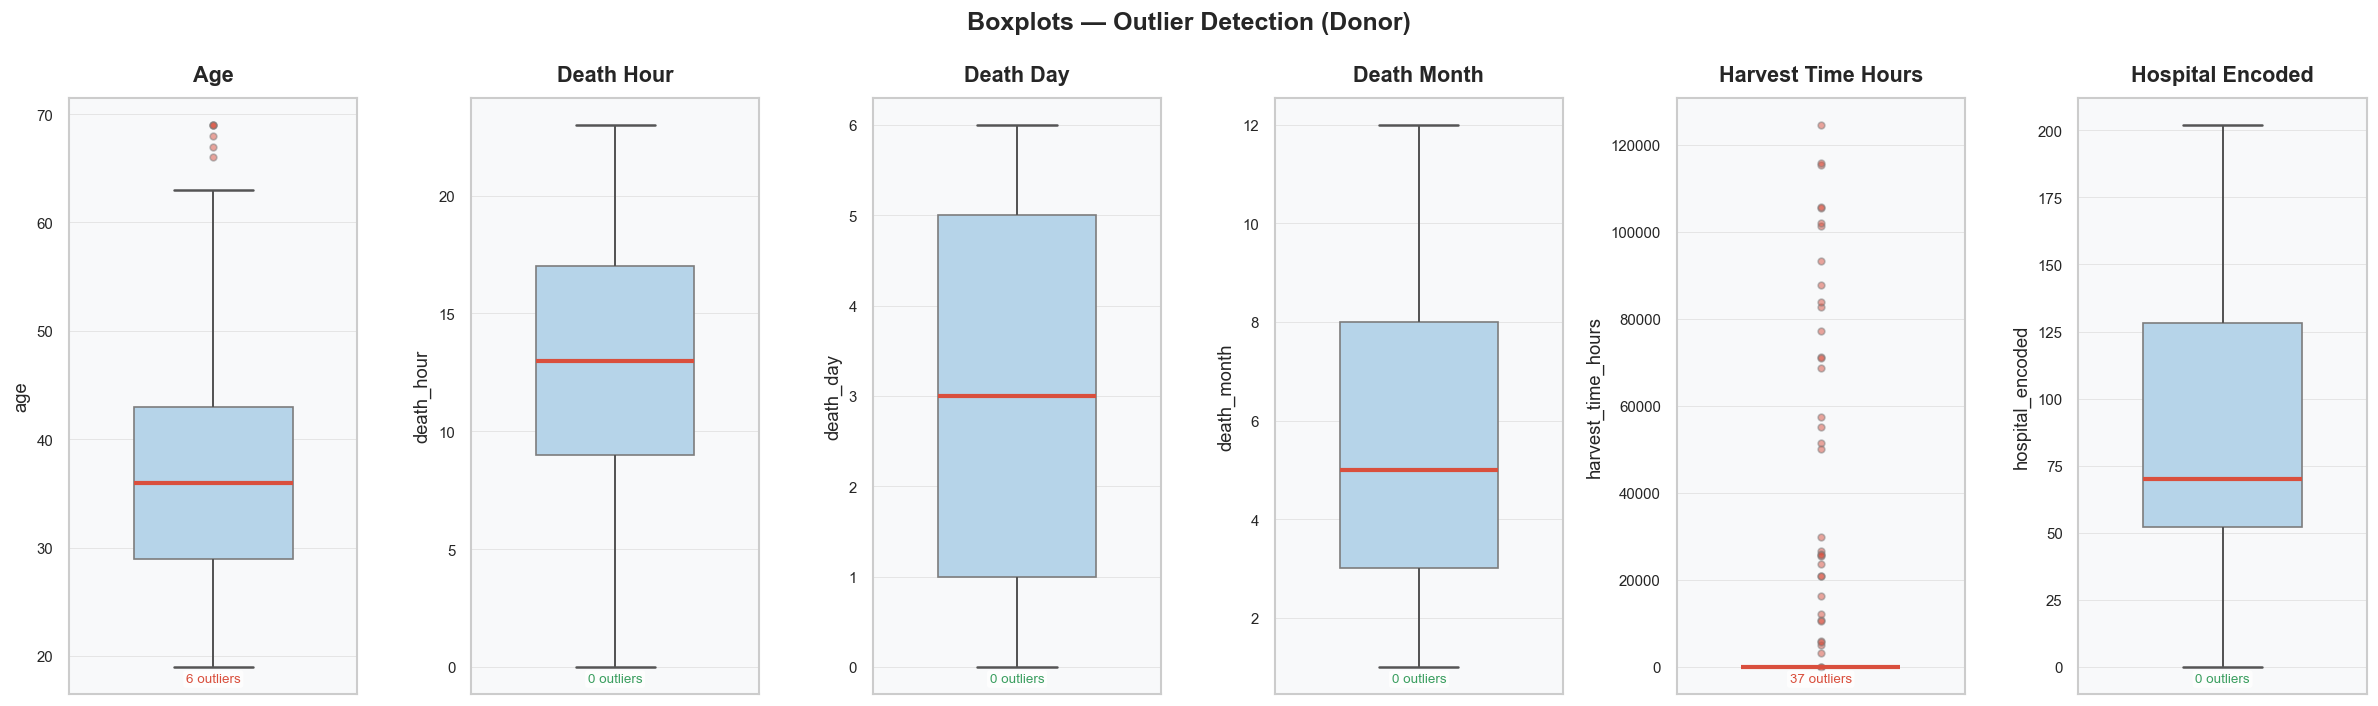

In [5]:
fig, axes = plt.subplots(1, len(CORE_CONT), figsize=(20, 6))
if len(CORE_CONT) == 1: axes = [axes]
for ax, col in zip(axes, CORE_CONT):
    valid = df[col][df[col] >= 0]
    sns.boxplot(y=valid, ax=ax, width=0.55, color="#AED6F1",
                medianprops=dict(color=C_RED, linewidth=2.5),
                whiskerprops=dict(color="#555", linewidth=1.2),
                capprops=dict(color="#555", linewidth=1.5),
                flierprops=dict(marker="o", markersize=4, markerfacecolor=C_RED, alpha=0.5, linestyle="none"))
    q1, q3 = valid.quantile(0.25), valid.quantile(0.75)
    n_out = ((valid < (q1-1.5*(q3-q1))) | (valid > (q3+1.5*(q3-q1)))).sum()
    ax.set_title(label(col))
    ax.text(0.5, 0.02, f"{n_out} outliers", transform=ax.transAxes, ha="center",
            fontsize=8, color=C_RED if n_out > 0 else C_GREEN,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
fig.suptitle("Boxplots — Outlier Detection (Donor)", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

### 1.3 Organs Being Donated — Distribution

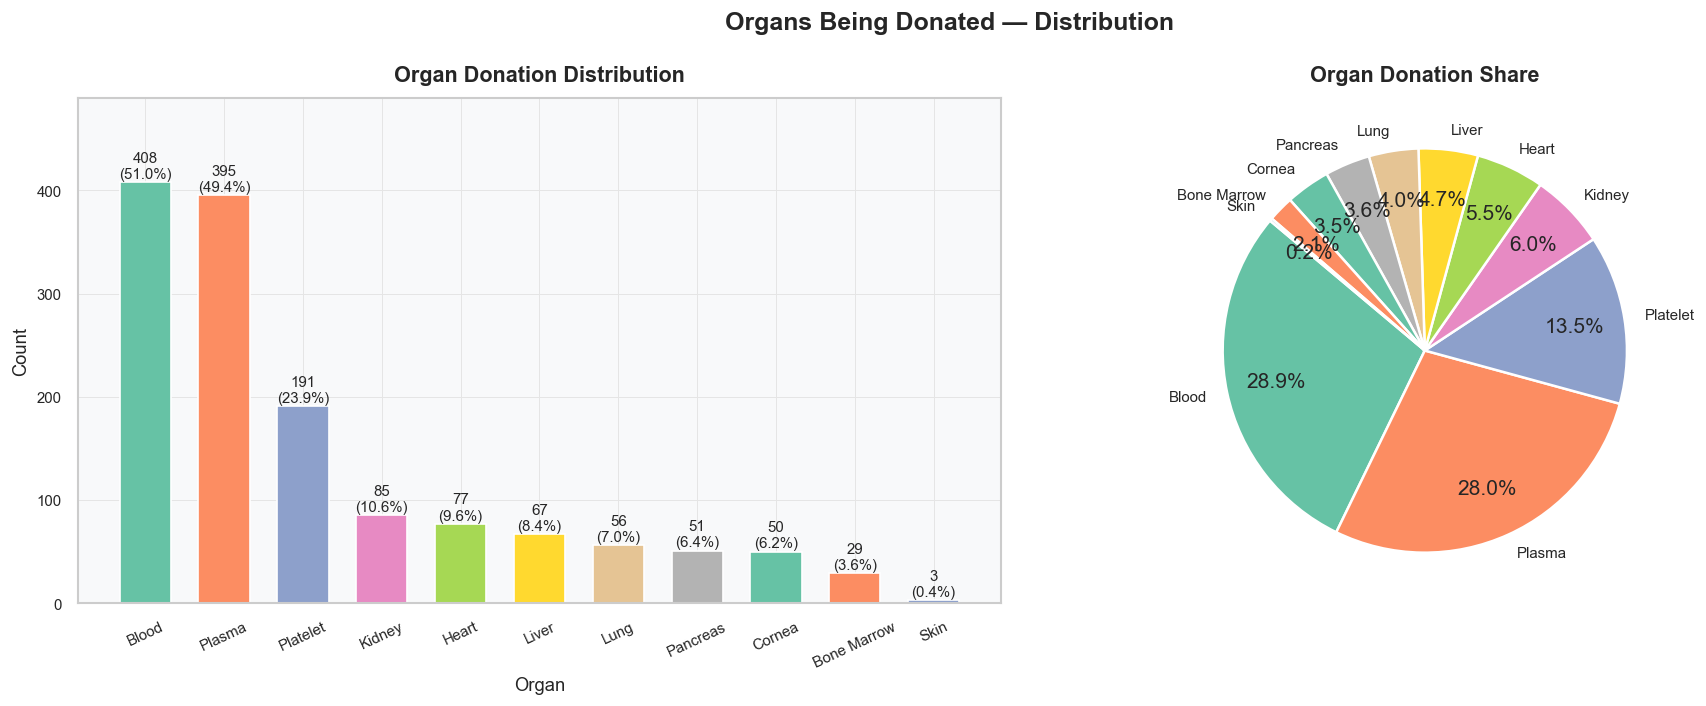

In [6]:
organ_series = pd.Series({c: df[c].sum() for c in ORGAN_COLS}).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("Set2", len(organ_series))
bars = axes[0].bar(organ_series.index, organ_series.values, color=colors, edgecolor="white", width=0.65)
for bar, val in zip(bars, organ_series.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Organ Donation Distribution"); axes[0].set_xlabel("Organ"); axes[0].set_ylabel("Count")
axes[0].set_ylim(0, organ_series.max()*1.2); axes[0].tick_params(axis="x", rotation=25)
axes[1].pie(organ_series.values, labels=organ_series.index, autopct="%1.1f%%", colors=colors,
            startangle=140, pctdistance=0.75, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Organ Donation Share")
fig.suptitle("Organs Being Donated — Distribution", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

### 1.4 Blood Type Distribution

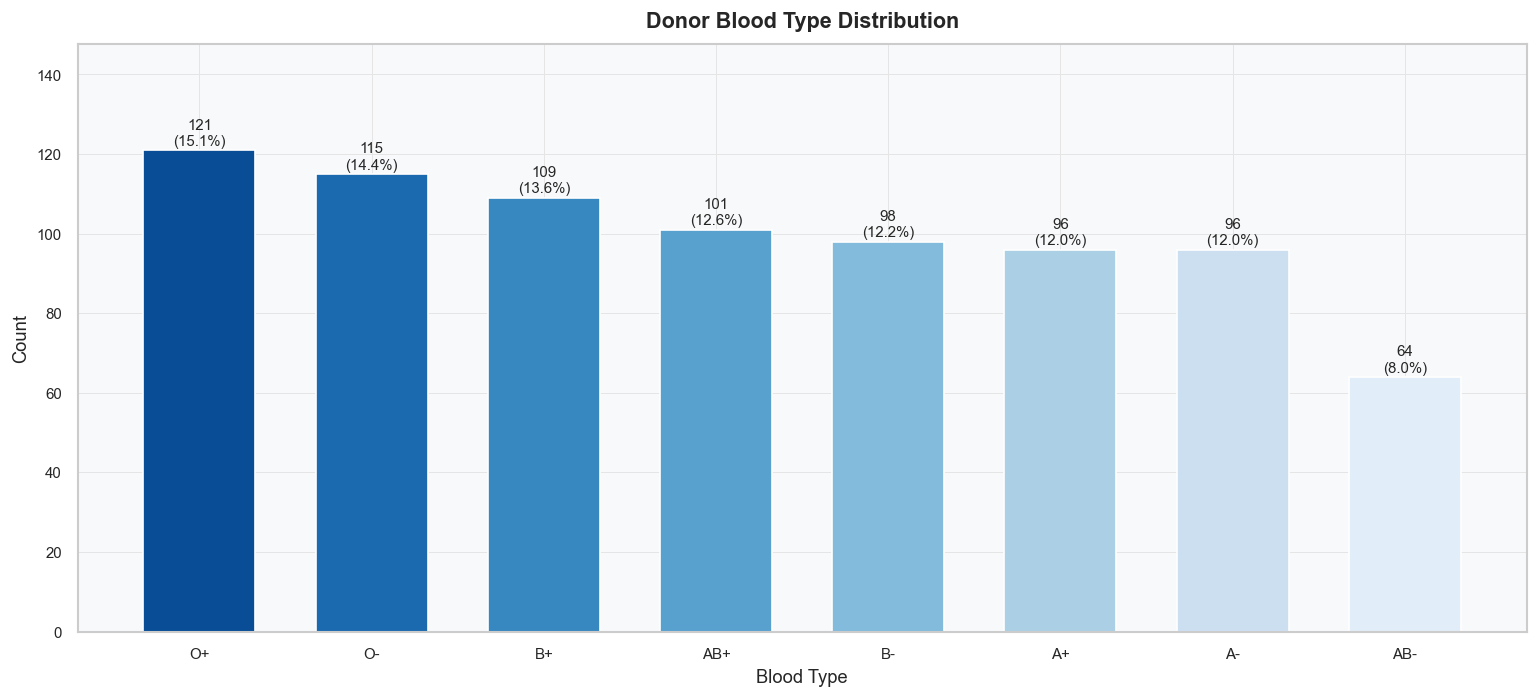

In [7]:
blood_series = pd.Series({c.replace("blood_",""):df[c].sum() for c in BLOOD_COLS}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(blood_series.index, blood_series.values,
              color=sns.color_palette("Blues_r", len(blood_series)), edgecolor="white", width=0.65)
for bar, val in zip(bars, blood_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Donor Blood Type Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Blood Type"); ax.set_ylabel("Count")
ax.set_ylim(0, blood_series.max()*1.22)
plt.tight_layout(); plt.show()

### 1.5 Gender, Hepatitis, Alive/Deceased Distribution

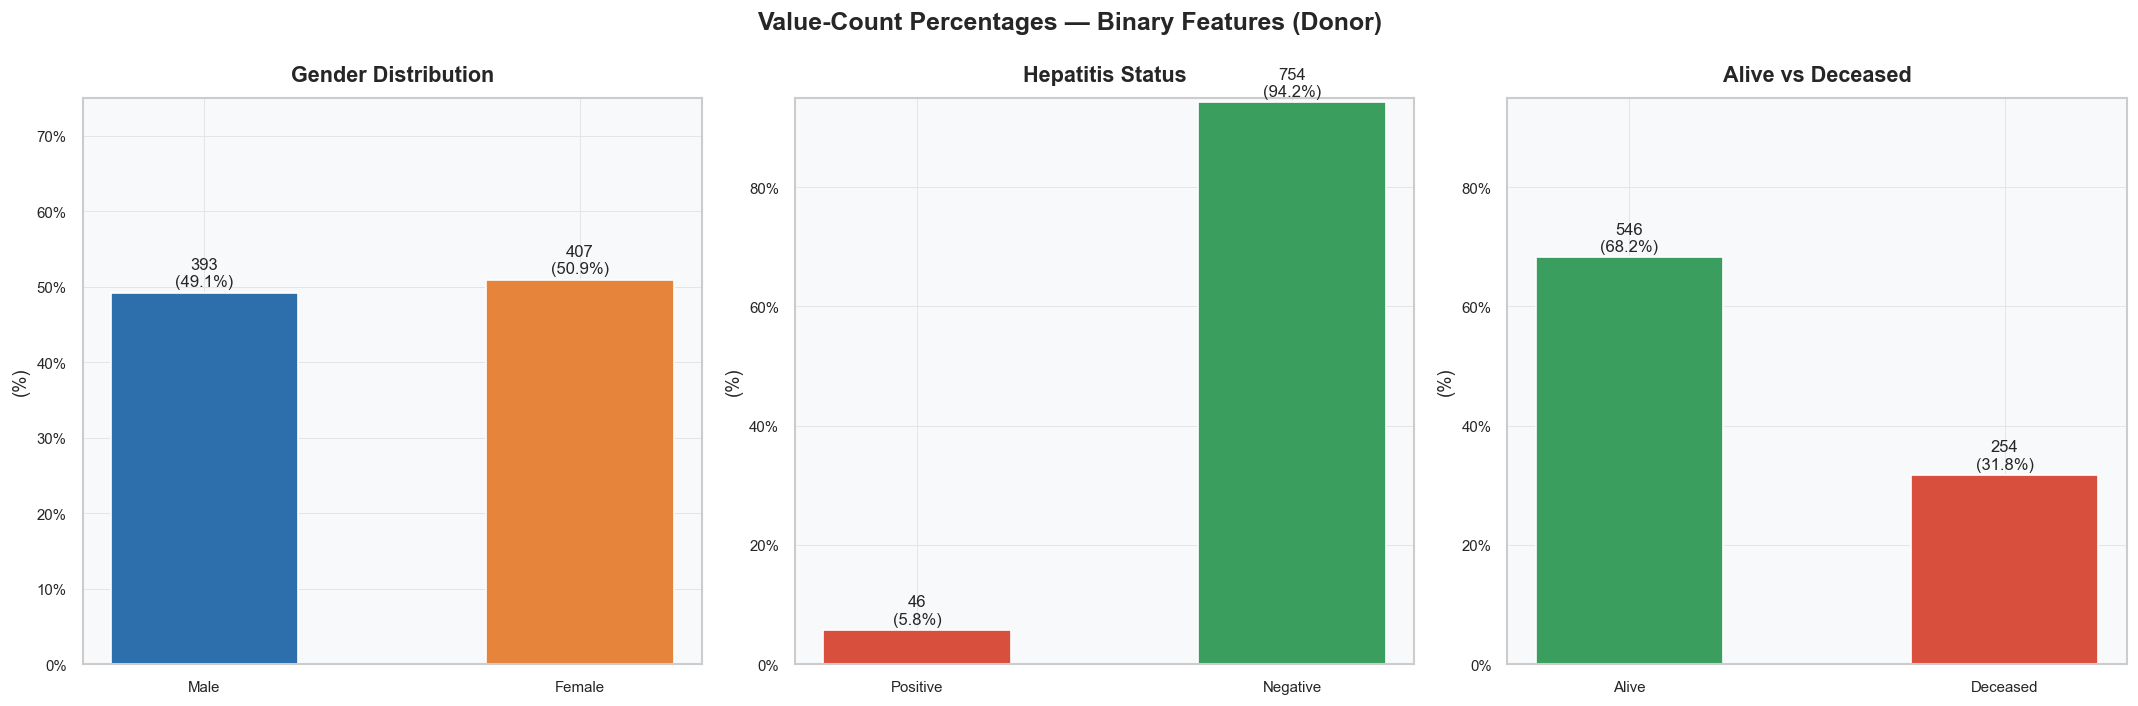

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Gender
g_data = pd.Series({"Male": df["gender_Male"].sum(), "Female": (df["gender_Male"]==0).sum()})
bars = axes[0].bar(g_data.index, g_data.values/len(df)*100, color=[C_BLUE,C_ORANGE], edgecolor="white", width=0.5)
for bar, val in zip(bars, g_data.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_ylim(0, 75); axes[0].set_title("Gender Distribution"); axes[0].set_ylabel("(%)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
# Hepatitis
h_data = pd.Series({"Positive": df["hepatitis_status"].sum(), "Negative": (df["hepatitis_status"]==0).sum()})
bars = axes[1].bar(h_data.index, h_data.values/len(df)*100, color=[C_RED,C_GREEN], edgecolor="white", width=0.5)
for bar, val in zip(bars, h_data.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[1].set_ylim(0, 95); axes[1].set_title("Hepatitis Status"); axes[1].set_ylabel("(%)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
# Alive/Deceased
a_col = "alive/deceased" if "alive/deceased" in df.columns else None
if a_col:
    a_data = pd.Series({"Alive": df[a_col].sum(), "Deceased": (df[a_col]==0).sum()})
    bars = axes[2].bar(a_data.index, a_data.values/len(df)*100, color=[C_GREEN,C_RED], edgecolor="white", width=0.5)
    for bar, val in zip(bars, a_data.values):
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
    axes[2].set_ylim(0, 95); axes[2].set_title("Alive vs Deceased"); axes[2].set_ylabel("(%)")
    axes[2].yaxis.set_major_formatter(mticker.PercentFormatter())
fig.suptitle("Value-Count Percentages — Binary Features (Donor)", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

### 1.6 Medical Conditions Prevalence

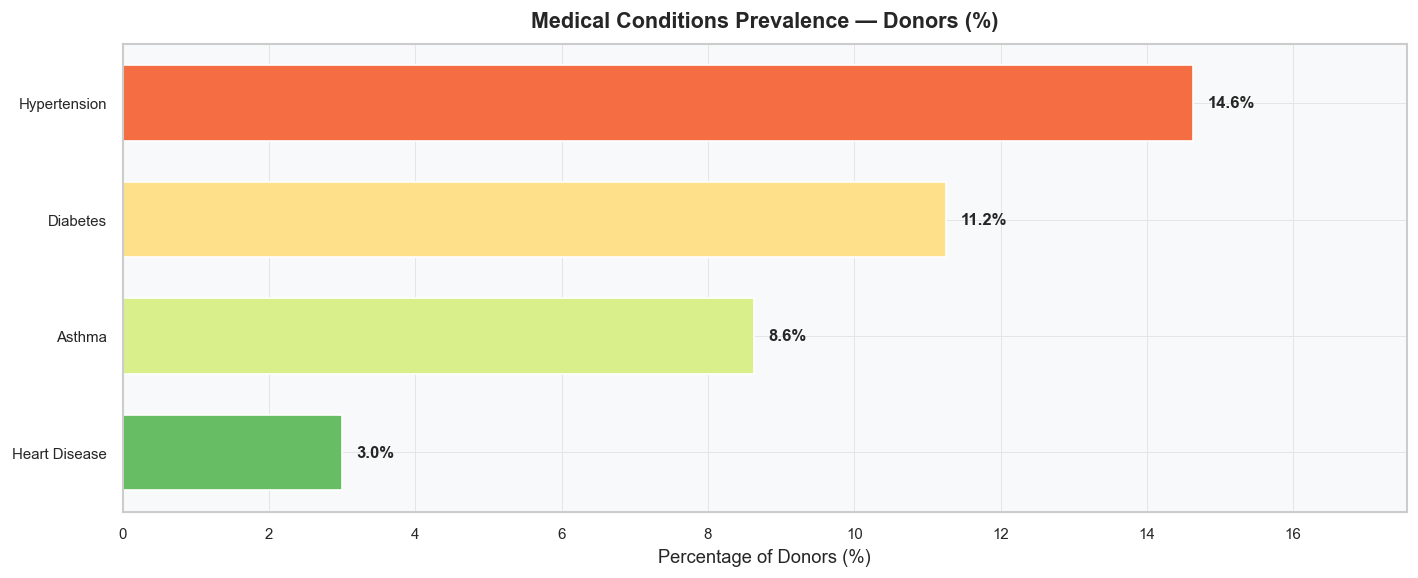

In [9]:
cond_pct = pd.Series({c.replace("Condition_","").replace("_"," "): df[c].mean()*100 for c in COND_COLS}).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(cond_pct.index, cond_pct.values,
               color=sns.color_palette("RdYlGn_r", len(cond_pct)), edgecolor="white", height=0.65)
for bar, val in zip(bars, cond_pct.values):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, cond_pct.max()*1.2)
ax.set_title("Medical Conditions Prevalence — Donors (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Percentage of Donors (%)")
plt.tight_layout(); plt.show()

### 1.7 Cause of Death Distribution

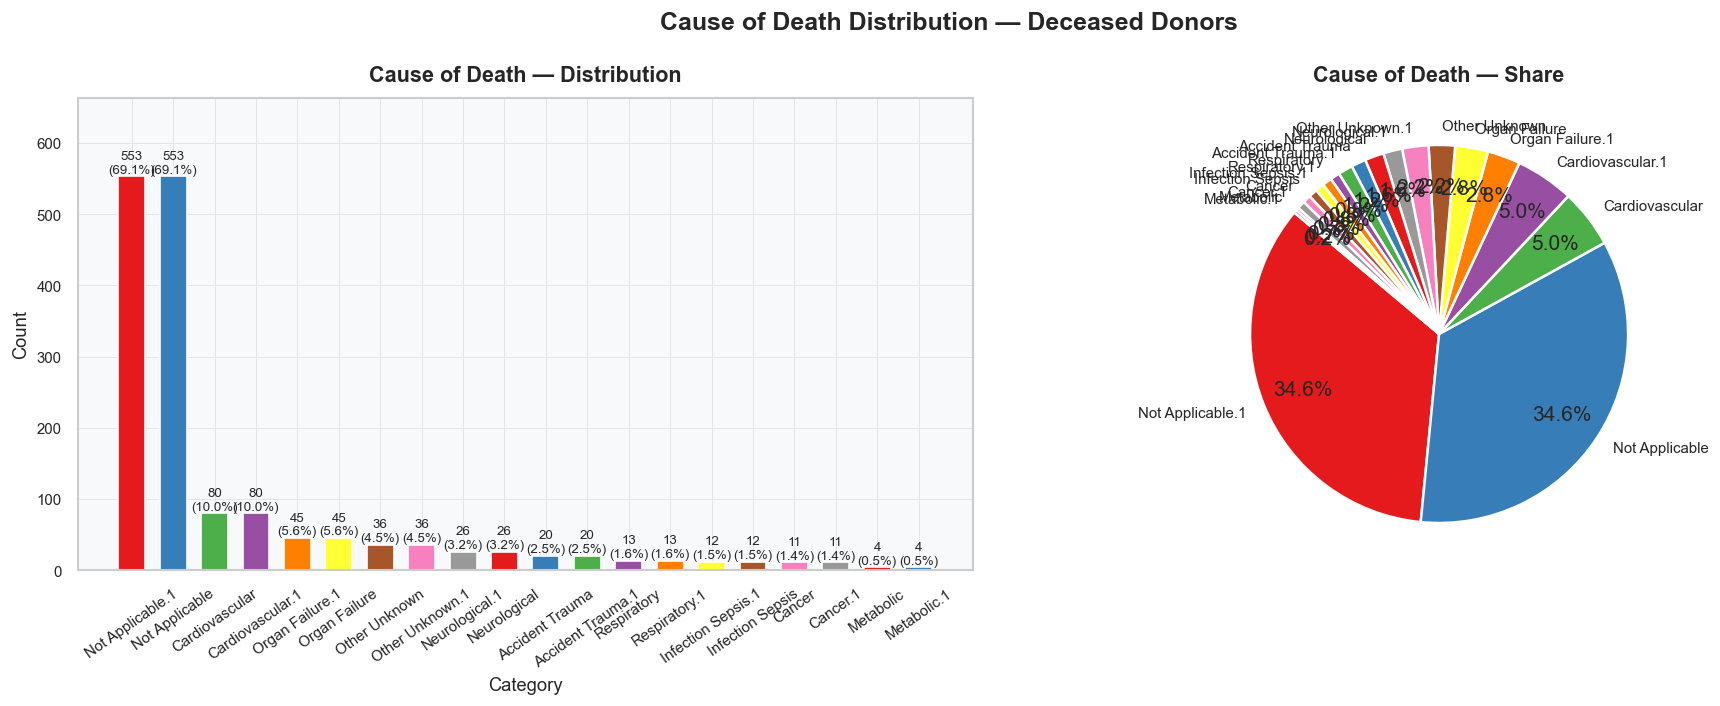

In [10]:
if CAUSE_COLS:
    cause_series = pd.Series({c.replace("Cause_","").replace("_"," "): df[c].sum() for c in CAUSE_COLS}).sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = sns.color_palette("Set1", len(cause_series))
    bars = axes[0].bar(cause_series.index, cause_series.values, color=colors, edgecolor="white", width=0.65)
    for bar, val in zip(bars, cause_series.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=8)
    axes[0].set_title("Cause of Death — Distribution"); axes[0].set_xlabel("Category"); axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=35); axes[0].set_ylim(0, cause_series.max()*1.2)
    axes[1].pie(cause_series.values, labels=cause_series.index, autopct="%1.1f%%", colors=colors,
                startangle=140, pctdistance=0.78, wedgeprops=dict(edgecolor="white", linewidth=1.5))
    axes[1].set_title("Cause of Death — Share")
    fig.suptitle("Cause of Death Distribution — Deceased Donors", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()

### 1.8 City Distribution

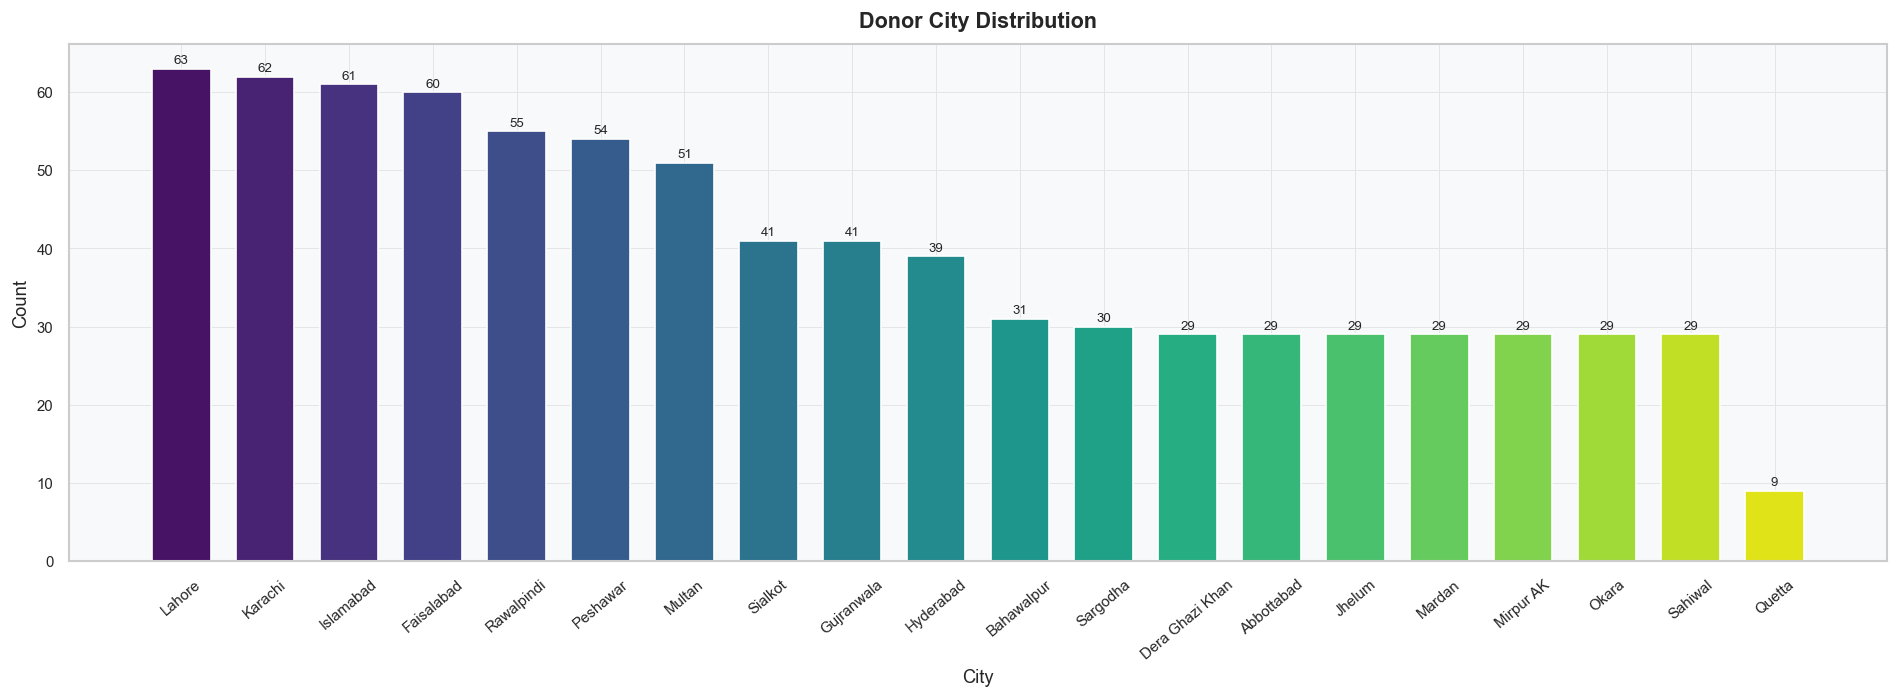

In [11]:
city_series = pd.Series({c.replace("City_",""):df[c].sum() for c in CITY_COLS}).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(city_series.index, city_series.values,
              color=sns.color_palette("viridis", len(city_series)), edgecolor="white", width=0.7)
for bar, val in zip(bars, city_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(val), ha="center", va="bottom", fontsize=8)
ax.set_title("Donor City Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("City"); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

### 1.9 Temporal Death & Harvest Patterns

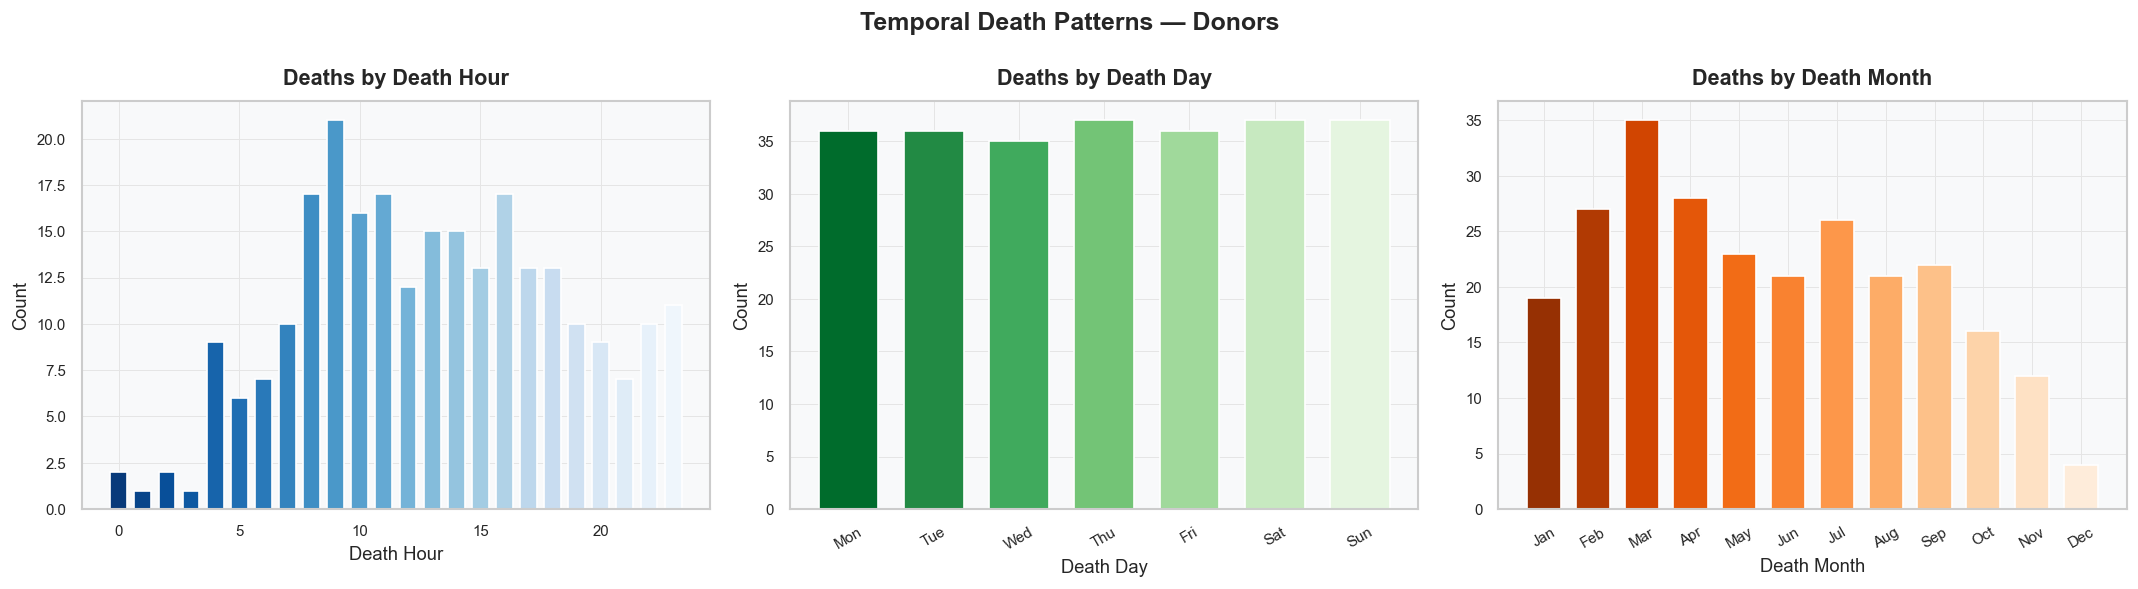

In [12]:
day_map   = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, cmap_, xmap) in zip(axes, [
        ("death_hour","Blues",None), ("death_day","Greens",day_map), ("death_month","Oranges",month_map)]):
    valid = df[col][df[col] >= 0]
    counts = valid.value_counts().sort_index()
    xlabels = [xmap[k] if xmap else k for k in counts.index]
    ax.bar(xlabels, counts.values, color=sns.color_palette(cmap_, len(counts))[::-1], edgecolor="white", width=0.7)
    ax.set_title(f"Deaths by {col.replace('_',' ').title()}")
    ax.set_xlabel(col.replace("_"," ").title()); ax.set_ylabel("Count")
    if xmap: ax.tick_params(axis="x", rotation=30)
fig.suptitle("Temporal Death Patterns — Donors", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 🔍 Section 2 — Bivariate Analysis

### 2.1 Correlation Heatmap — Core + Clinical Features

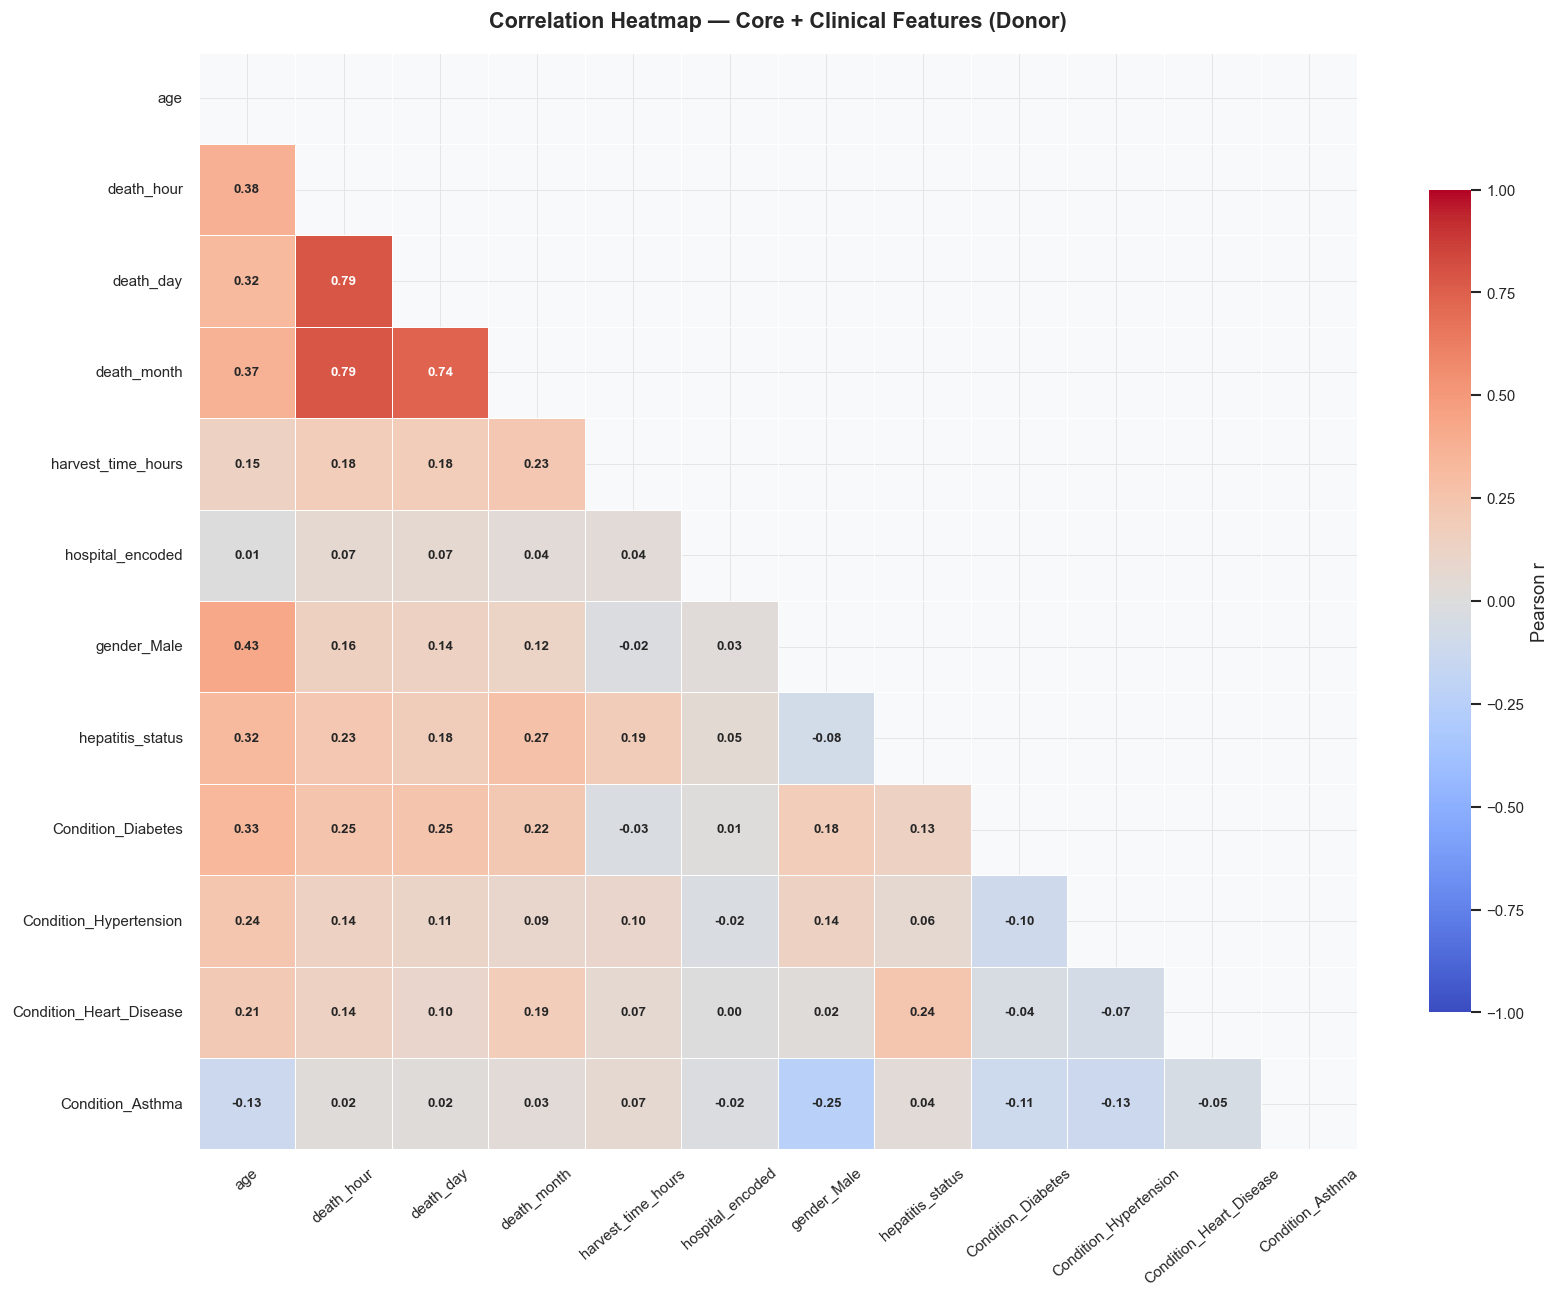

In [13]:
HEAT_COLS = CORE_CONT + ["gender_Male","hepatitis_status"] + COND_COLS
HEAT_COLS = [c for c in HEAT_COLS if c in df.columns]
corr = df[HEAT_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size":8,"weight":"bold"},
            cbar_kws={"shrink":0.75,"label":"Pearson r"}, ax=ax)
ax.set_title("Correlation Heatmap — Core + Clinical Features (Donor)", fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=40); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

### 2.2 Scatterplots — Key Numerical Pairs (by Gender)

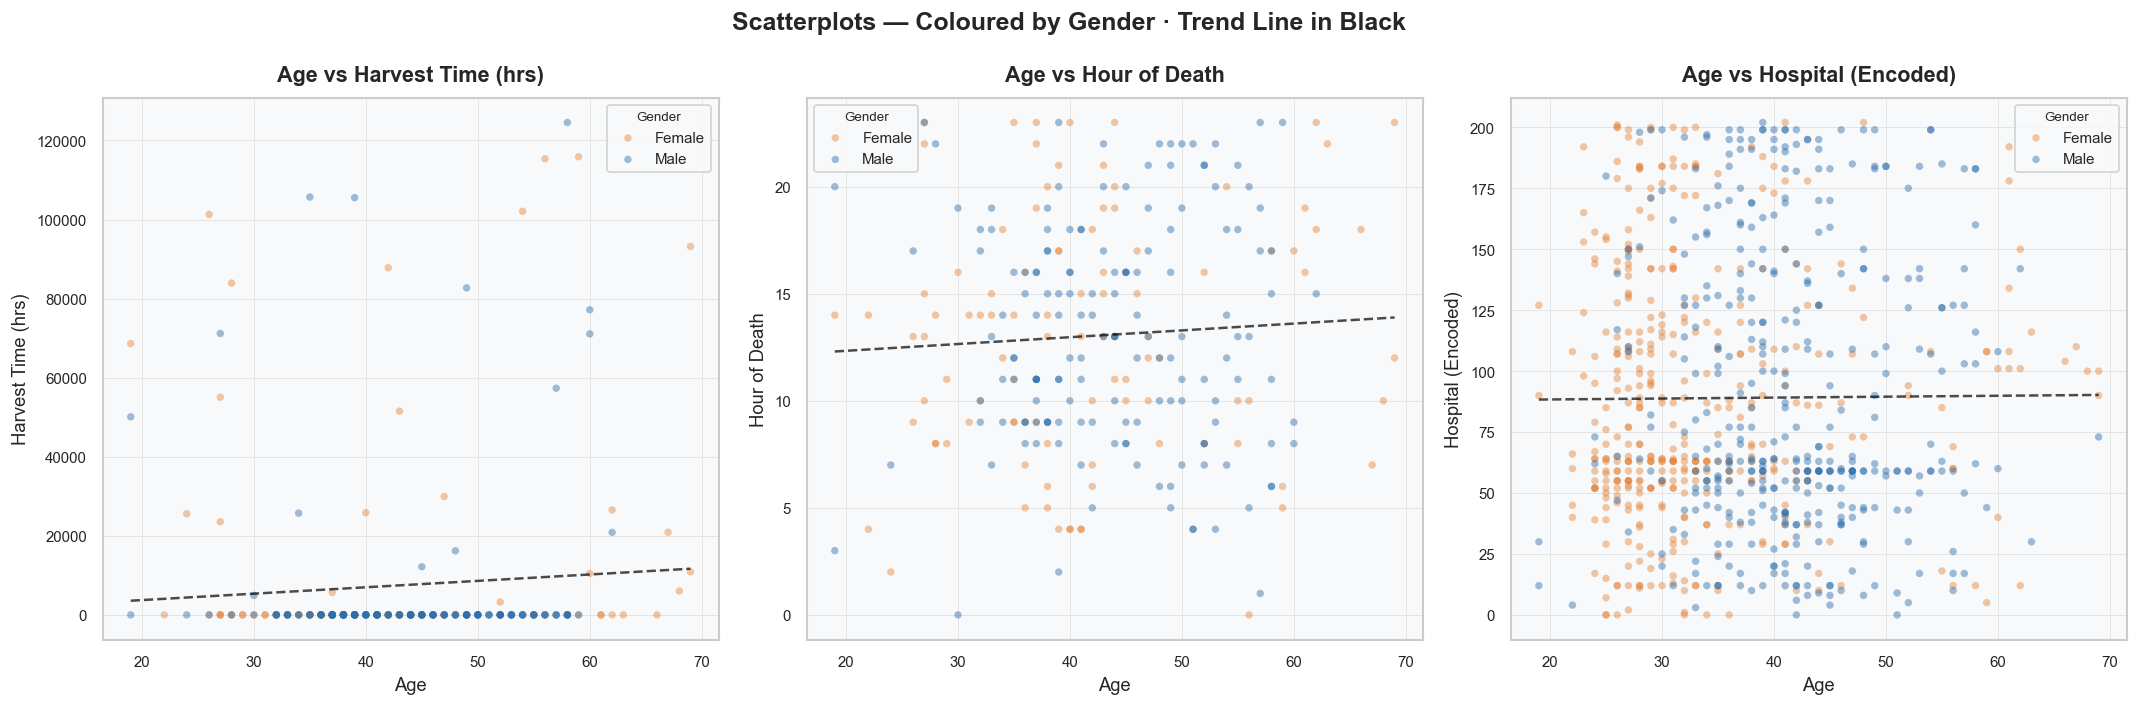

In [14]:
pairs = [("age","harvest_time_hours","Age","Harvest Time (hrs)"),
         ("age","death_hour","Age","Hour of Death"),
         ("age","hospital_encoded","Age","Hospital (Encoded)")]
pairs = [(cx,cy,lx,ly) for cx,cy,lx,ly in pairs if cx in df.columns and cy in df.columns]
fig, axes = plt.subplots(1, len(pairs), figsize=(18, 6))
if len(pairs)==1: axes=[axes]
for ax, (cx,cy,lx,ly) in zip(axes, pairs):
    for gender, gdf in df.groupby("gender_Male"):
        gname = "Male" if gender==1 else "Female"
        valid = gdf[[cx,cy]][(gdf[cy]>=0) & (gdf[cx]>=0)]
        ax.scatter(valid[cx], valid[cy], color=GENDER_PALETTE[gname], alpha=0.45, s=20, edgecolors="none", label=gname)
    valid_all = df[[cx,cy]][(df[cy]>=0)&(df[cx]>=0)]
    z = np.polyfit(valid_all[cx], valid_all[cy], 1)
    xline = np.linspace(valid_all[cx].min(), valid_all[cx].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color="black", lw=1.5, linestyle="--", alpha=0.7)
    ax.set_xlabel(lx); ax.set_ylabel(ly); ax.set_title(f"{lx} vs {ly}")
    ax.legend(title="Gender", title_fontsize=8)
fig.suptitle("Scatterplots — Coloured by Gender · Trend Line in Black", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

### 2.3 Pairplot — Key Continuous Features

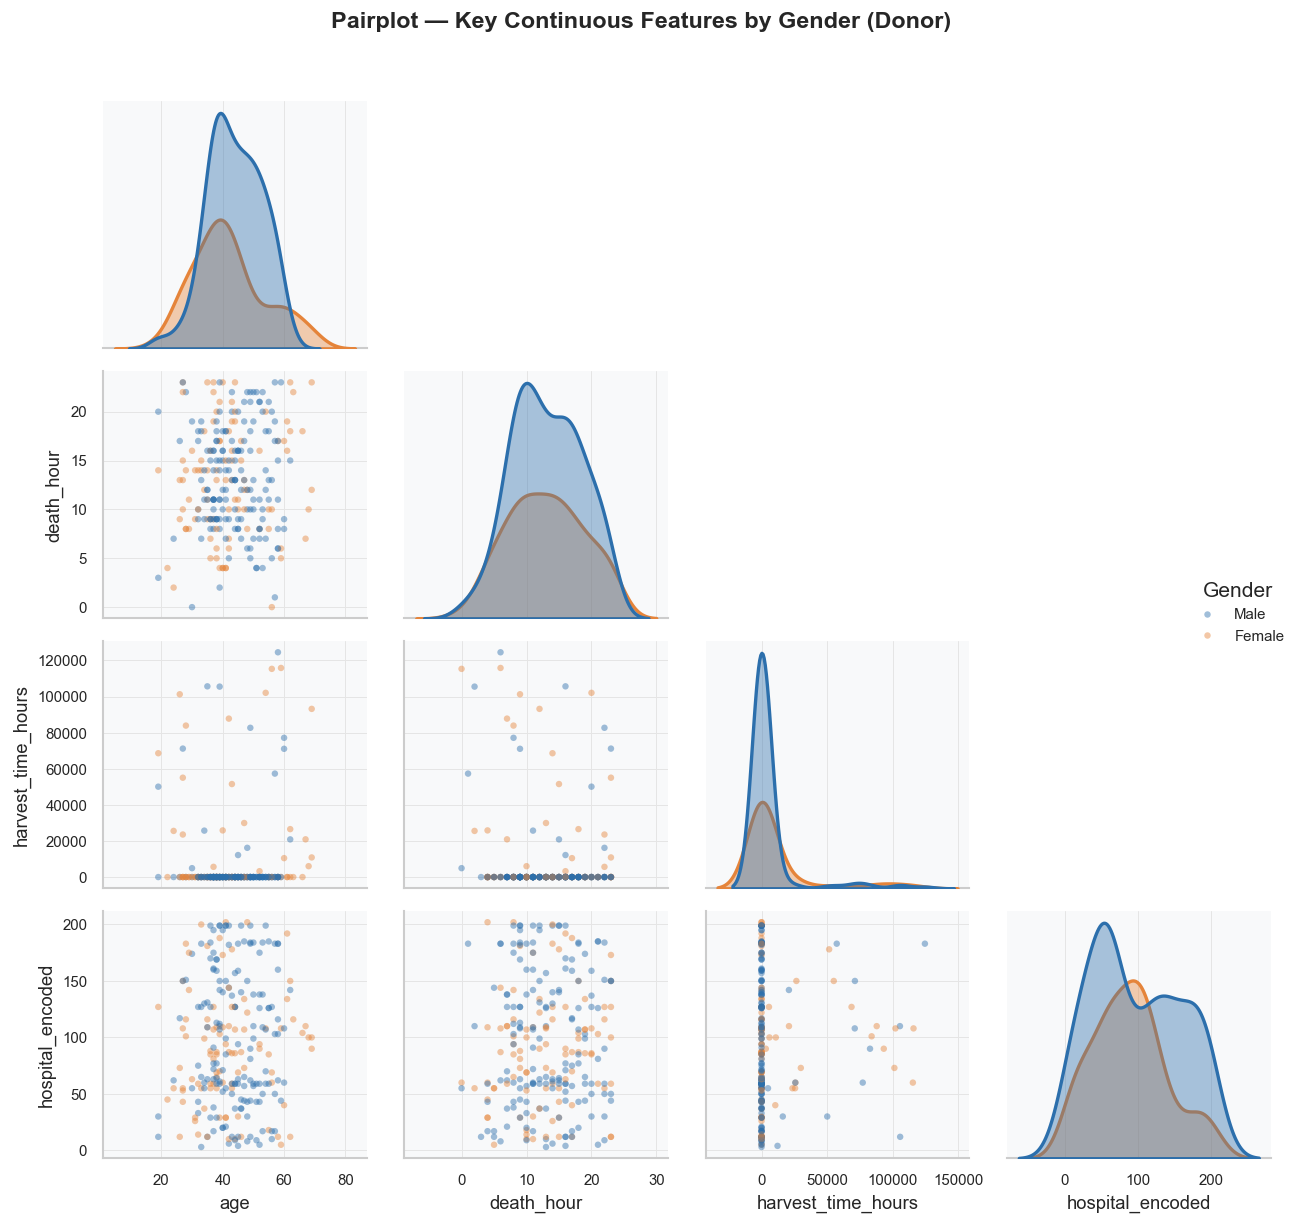

In [15]:
pair_cols = [c for c in ["age","death_hour","harvest_time_hours","hospital_encoded"] if c in df.columns]
pair_df = df[pair_cols + ["gender_Male"]].copy()
pair_df = pair_df[(pair_df >= 0).all(axis=1)]
pair_df["Gender"] = pair_df["gender_Male"].map({1:"Male",0:"Female"})
g = sns.pairplot(pair_df.drop(columns="gender_Male"), hue="Gender", palette=GENDER_PALETTE,
                 diag_kind="kde", plot_kws={"alpha":0.45,"s":15,"edgecolor":"none"},
                 diag_kws={"linewidth":2,"fill":True,"alpha":0.4}, corner=True)
g.figure.suptitle("Pairplot — Key Continuous Features by Gender (Donor)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 2.4 Age Distribution by Organ Being Donated

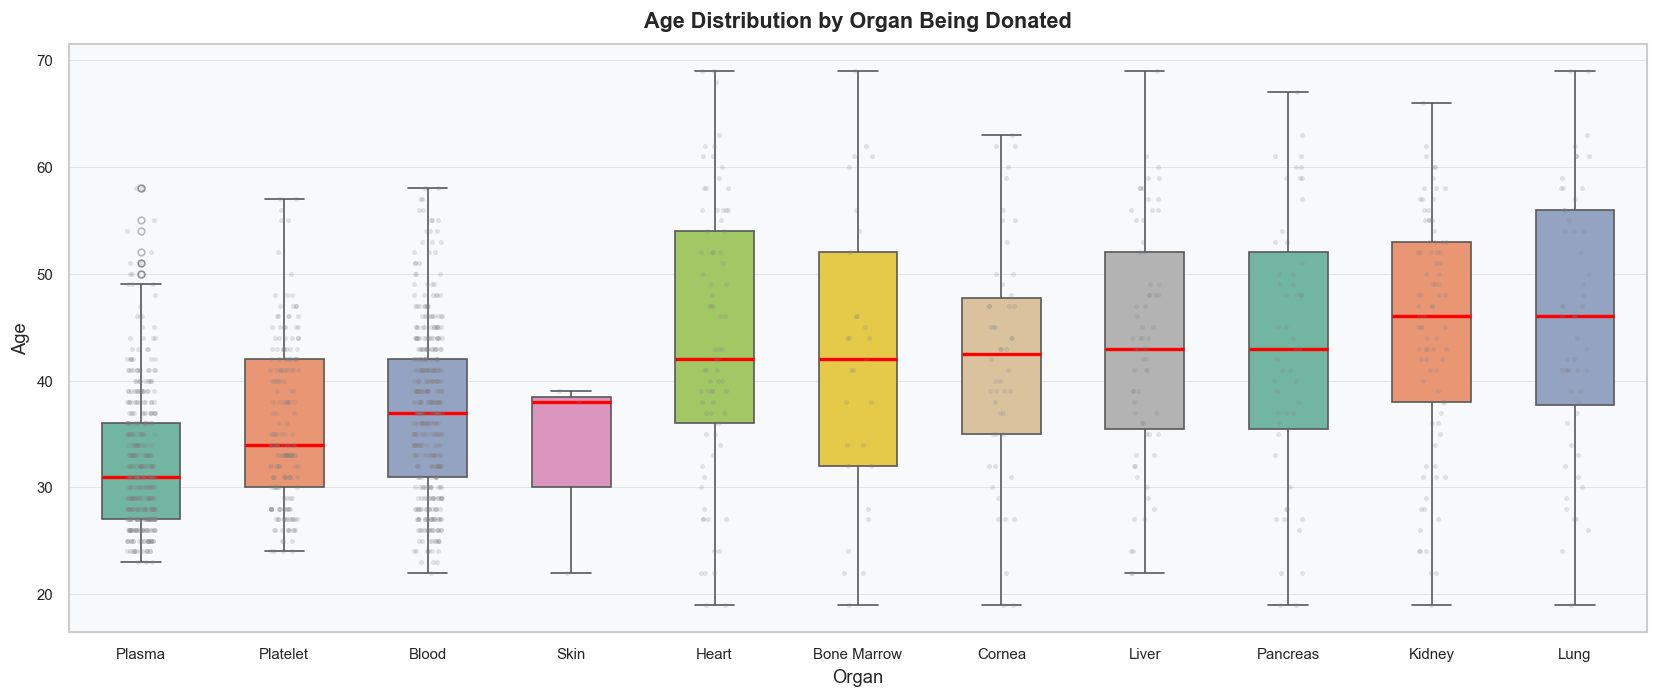

In [16]:
rows = [{"Organ":c, "Age":v} for c in ORGAN_COLS for v in df.loc[df[c]==1,"age"]]
odf = pd.DataFrame(rows)
order = odf.groupby("Organ")["Age"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=odf, x="Organ", y="Age", order=order, palette="Set2", width=0.55, ax=ax,
            medianprops=dict(color="red",linewidth=2),
            flierprops=dict(marker="o",markersize=4,alpha=0.4,color=C_RED))
sns.stripplot(data=odf, x="Organ", y="Age", order=order, color="gray", alpha=0.2, size=3, jitter=True, ax=ax)
ax.set_title("Age Distribution by Organ Being Donated", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("Age")
plt.tight_layout(); plt.show()

### 2.5 Harvest Time by Organ Type

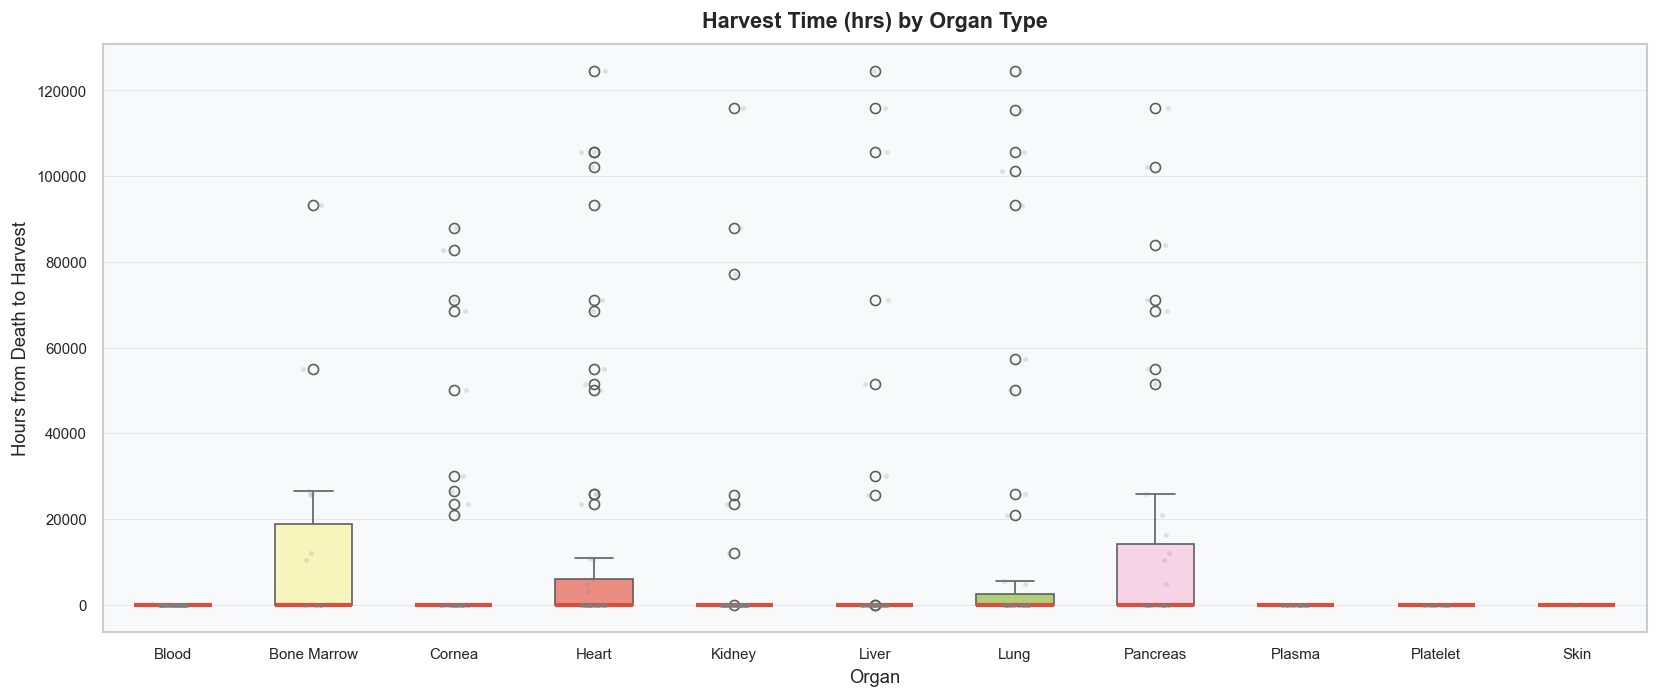

In [17]:
if "harvest_time_hours" in df.columns:
    valid_harvest = df[df["harvest_time_hours"] >= 0]
    rows_h = [{"Organ":c, "Harvest_hrs":v} for c in ORGAN_COLS for v in valid_harvest.loc[valid_harvest[c]==1,"harvest_time_hours"]]
    hdf = pd.DataFrame(rows_h)
    fig, ax = plt.subplots(figsize=(14, 6))
    order_h = hdf.groupby("Organ")["Harvest_hrs"].median().sort_values().index.tolist()
    sns.boxplot(data=hdf, x="Organ", y="Harvest_hrs", order=order_h, palette="Set3", width=0.55, ax=ax,
                medianprops=dict(color=C_RED, linewidth=2.5))
    sns.stripplot(data=hdf, x="Organ", y="Harvest_hrs", order=order_h, color="gray", alpha=0.2, size=3, jitter=True, ax=ax)
    ax.set_title("Harvest Time (hrs) by Organ Type", fontsize=13, fontweight="bold")
    ax.set_xlabel("Organ"); ax.set_ylabel("Hours from Death to Harvest")
    plt.tight_layout(); plt.show()

### 2.6 Hepatitis Status by Organ Being Donated

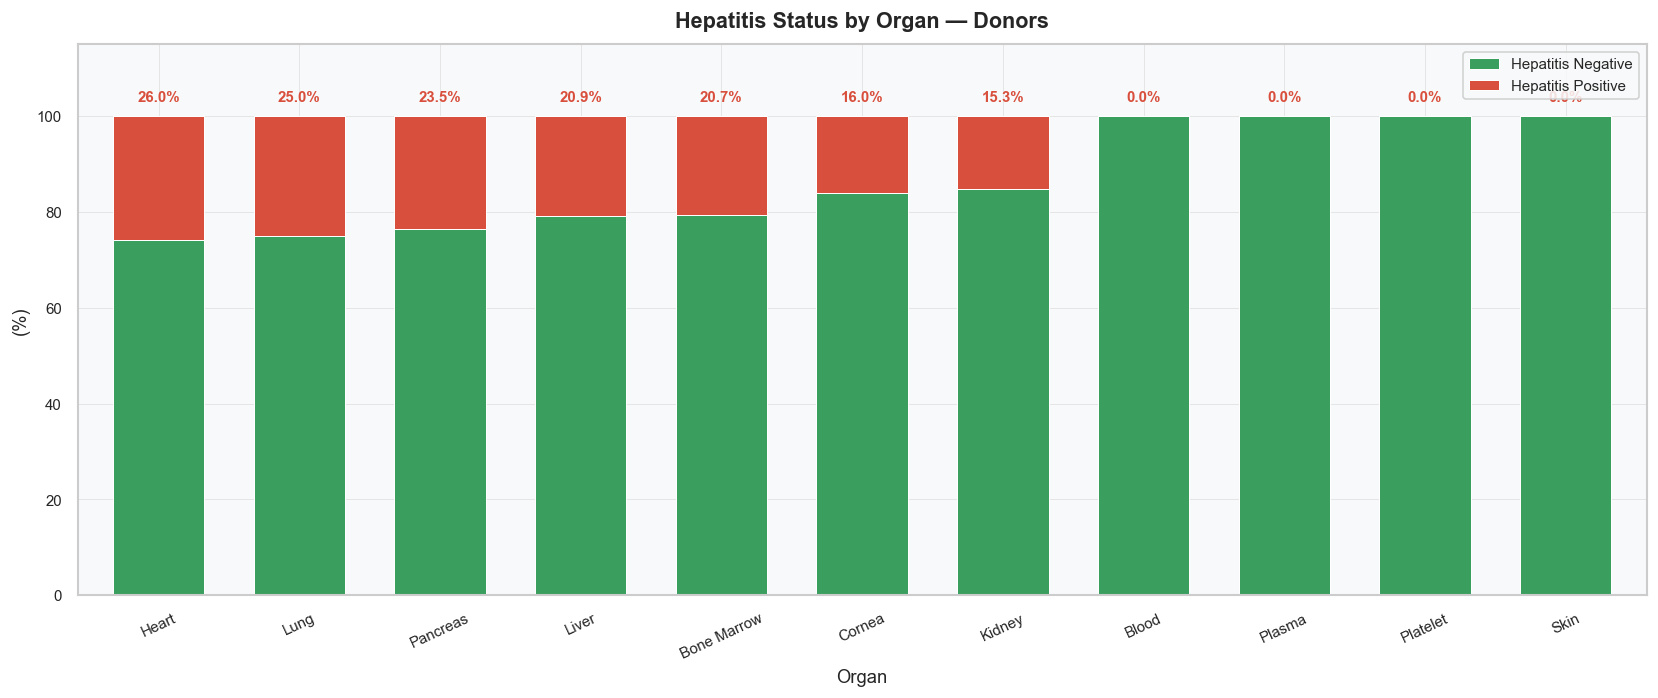

In [18]:
hep_by = {c: {"Positive": df[df[c]==1]["hepatitis_status"].mean()*100,
              "Negative": (1-df[df[c]==1]["hepatitis_status"].mean())*100} for c in ORGAN_COLS}
hdf2 = pd.DataFrame(hep_by).T.sort_values("Positive", ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))
hdf2[["Negative","Positive"]].plot(kind="bar", stacked=True, ax=ax,
    color=[C_GREEN,C_RED], edgecolor="white", linewidth=0.6, width=0.65)
for i,(idx,row) in enumerate(hdf2.iterrows()):
    ax.text(i, 103, f"{row['Positive']:.1f}%", ha="center", fontsize=9, color=C_RED, fontweight="bold")
ax.set_ylim(0, 115); ax.set_title("Hepatitis Status by Organ — Donors", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("(%)"); ax.tick_params(axis="x",rotation=25)
ax.legend(["Hepatitis Negative","Hepatitis Positive"])
plt.tight_layout(); plt.show()

### 2.7 Medical Conditions Prevalence by Gender

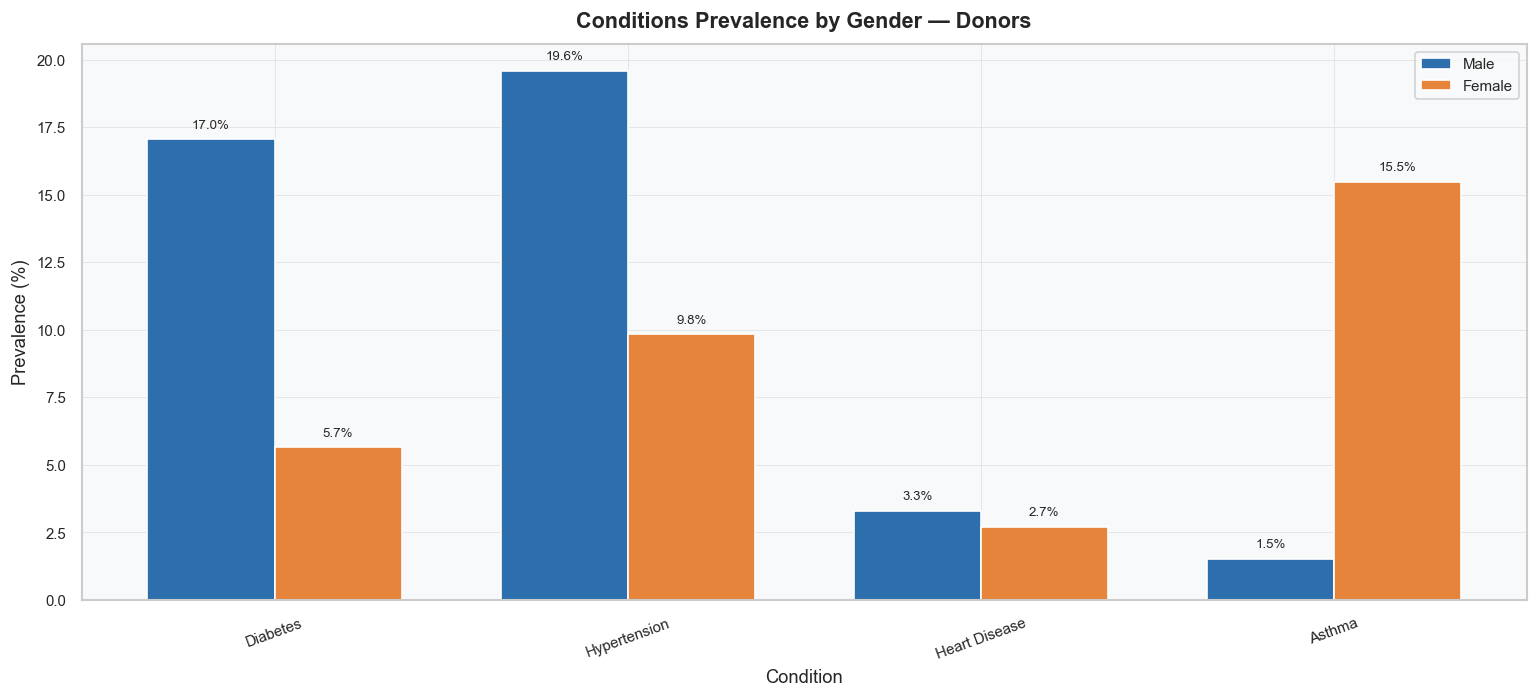

In [19]:
cg = {c.replace("Condition_","").replace("_"," "):
      {"Male":df.loc[df["gender_Male"]==1,c].mean()*100, "Female":df.loc[df["gender_Male"]==0,c].mean()*100}
      for c in COND_COLS}
cg_df = pd.DataFrame(cg).T
x = np.arange(len(cg_df)); w = 0.36
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w/2, cg_df["Male"],   w, color=C_BLUE,   label="Male",   edgecolor="white")
b2 = ax.bar(x+w/2, cg_df["Female"], w, color=C_ORANGE, label="Female", edgecolor="white")
for bar in [*b1,*b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cg_df.index, rotation=20)
ax.set_title("Conditions Prevalence by Gender — Donors", fontsize=13, fontweight="bold")
ax.set_xlabel("Condition"); ax.set_ylabel("Prevalence (%)"); ax.legend()
plt.tight_layout(); plt.show()

---
## 🌐 Section 3 — Multivariate Analysis

### 3.1 Full Correlation Matrix — All Numeric Features

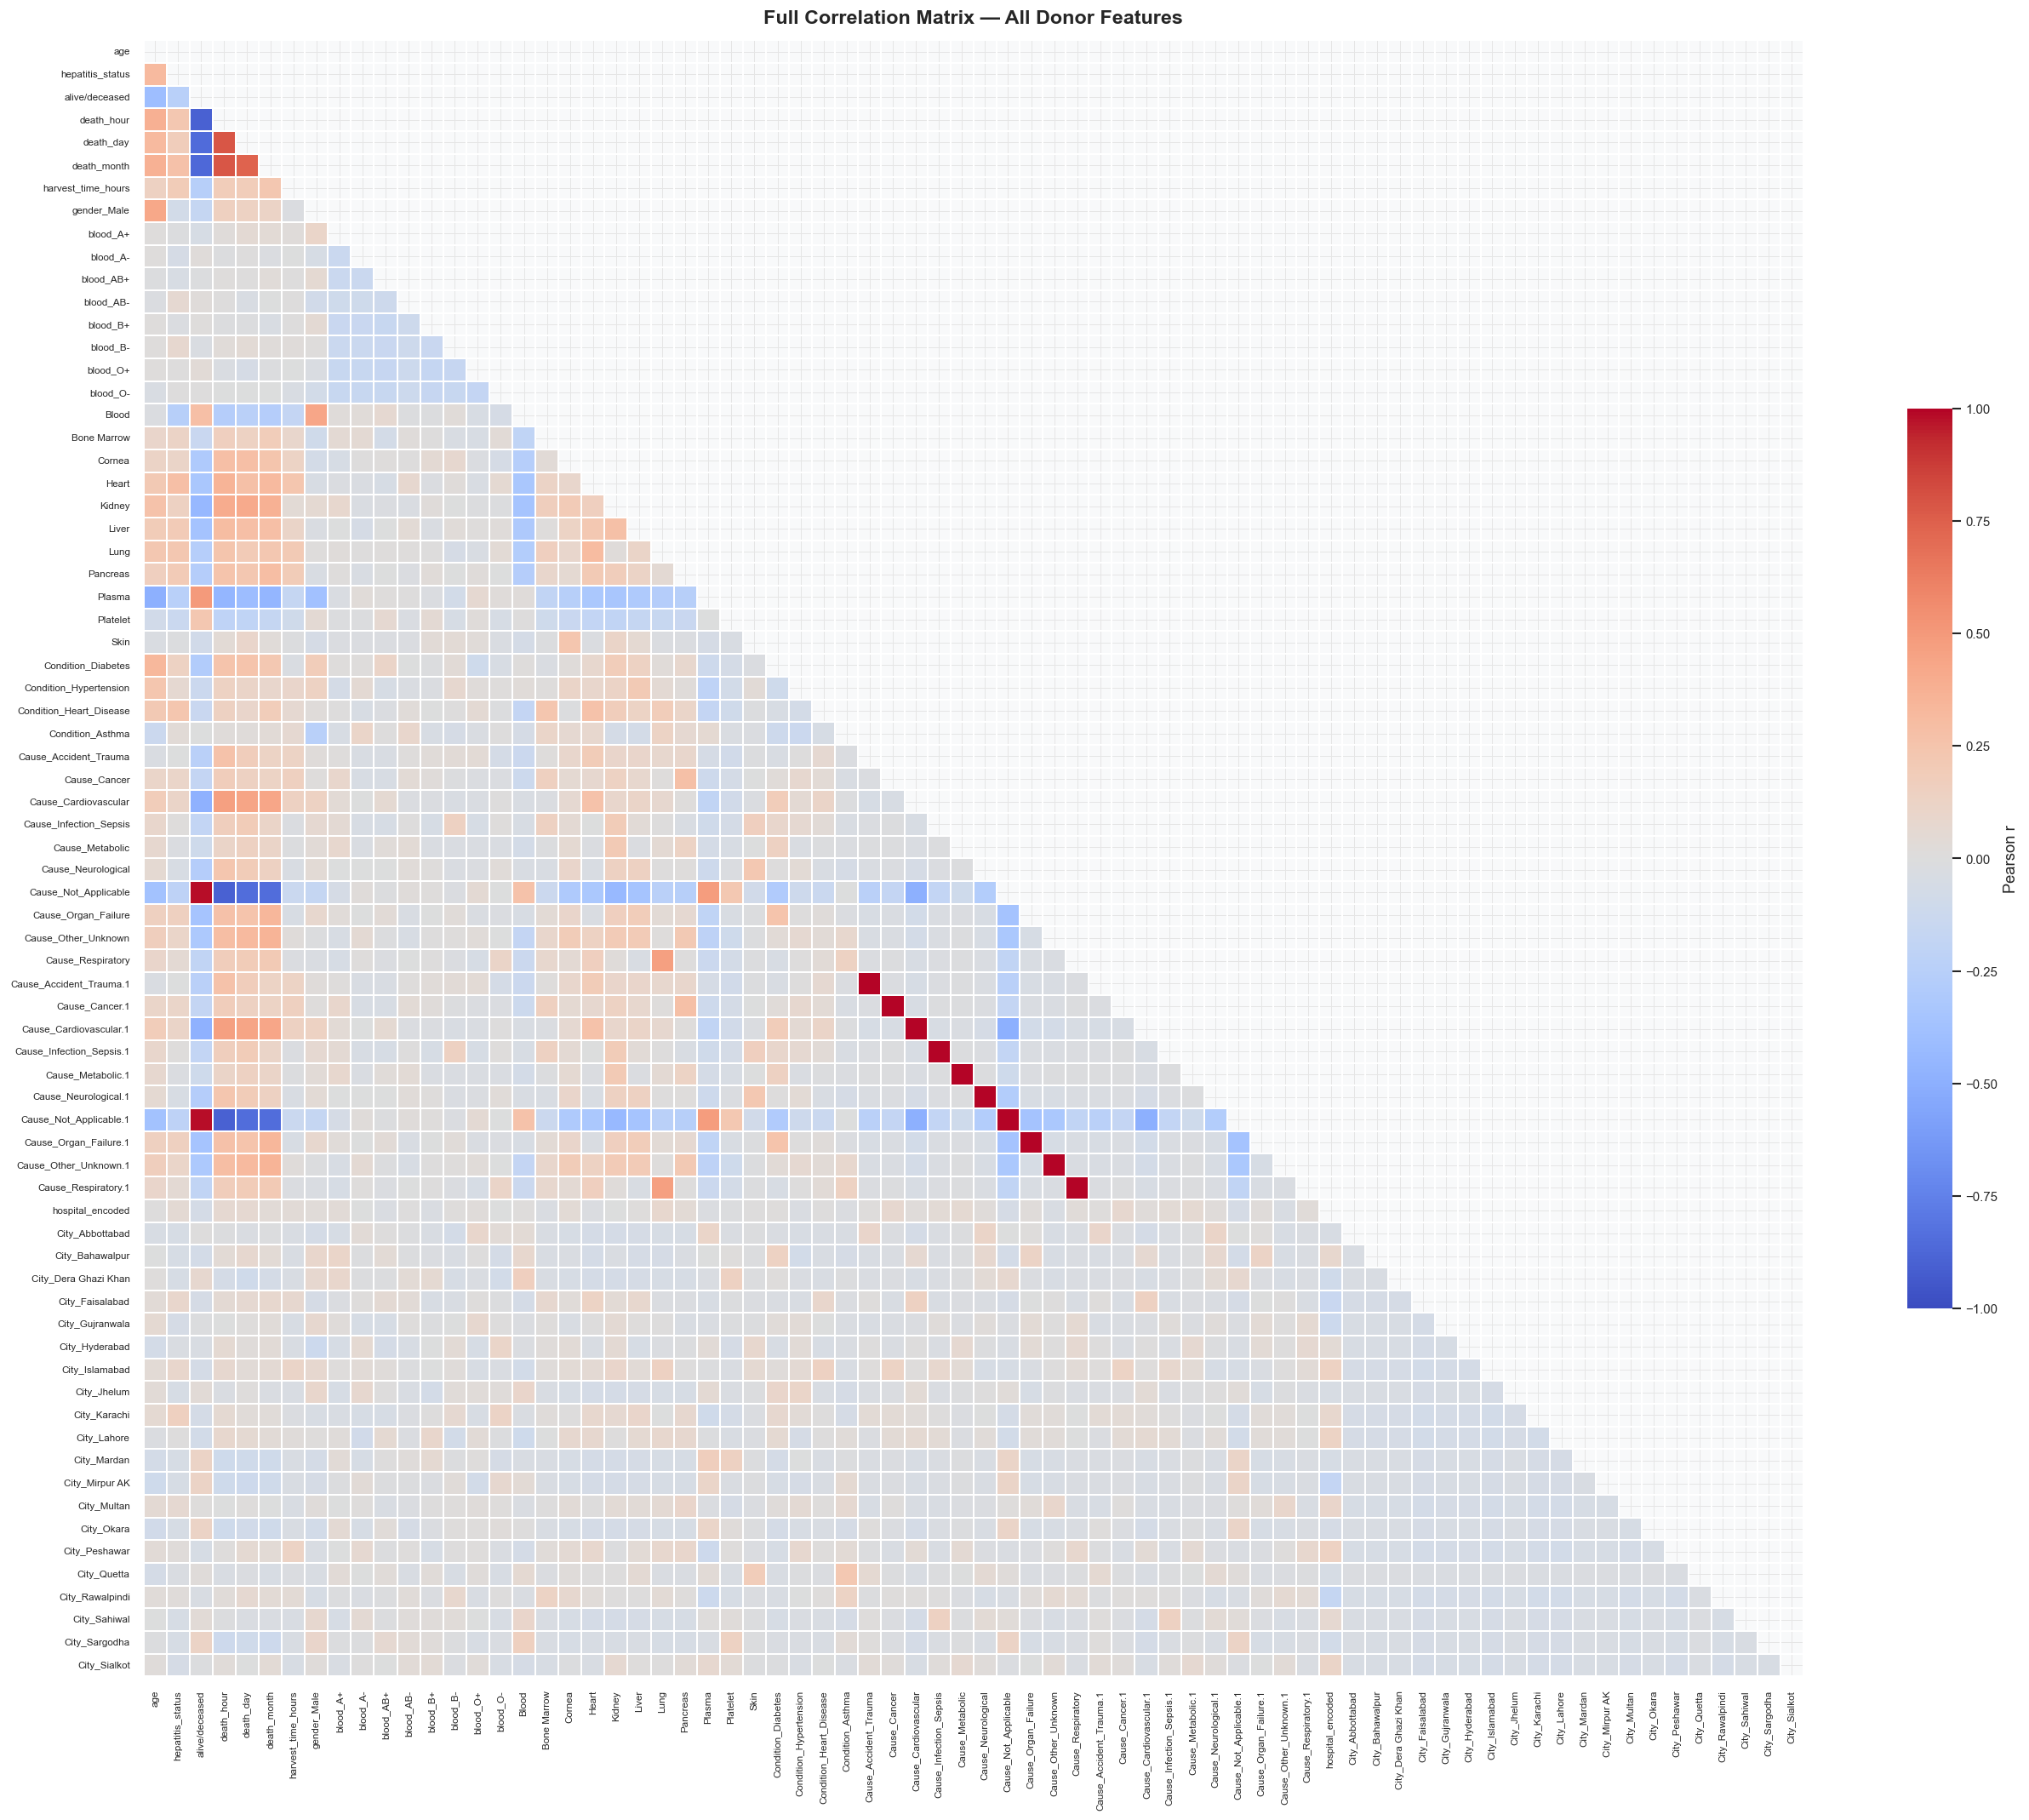

In [20]:
corr_full = df[all_num].corr()
mask_full = np.triu(np.ones_like(corr_full, dtype=bool))
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(corr_full, mask=mask_full, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.2, linecolor="white", annot=False,
            cbar_kws={"shrink":0.55,"label":"Pearson r"}, ax=ax)
ax.set_title("Full Correlation Matrix — All Donor Features", fontsize=14, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=90, labelsize=7); ax.tick_params(axis="y", rotation=0, labelsize=7)
plt.tight_layout(); plt.show()

### 3.2 Violin — Age by Organ × Hepatitis Status

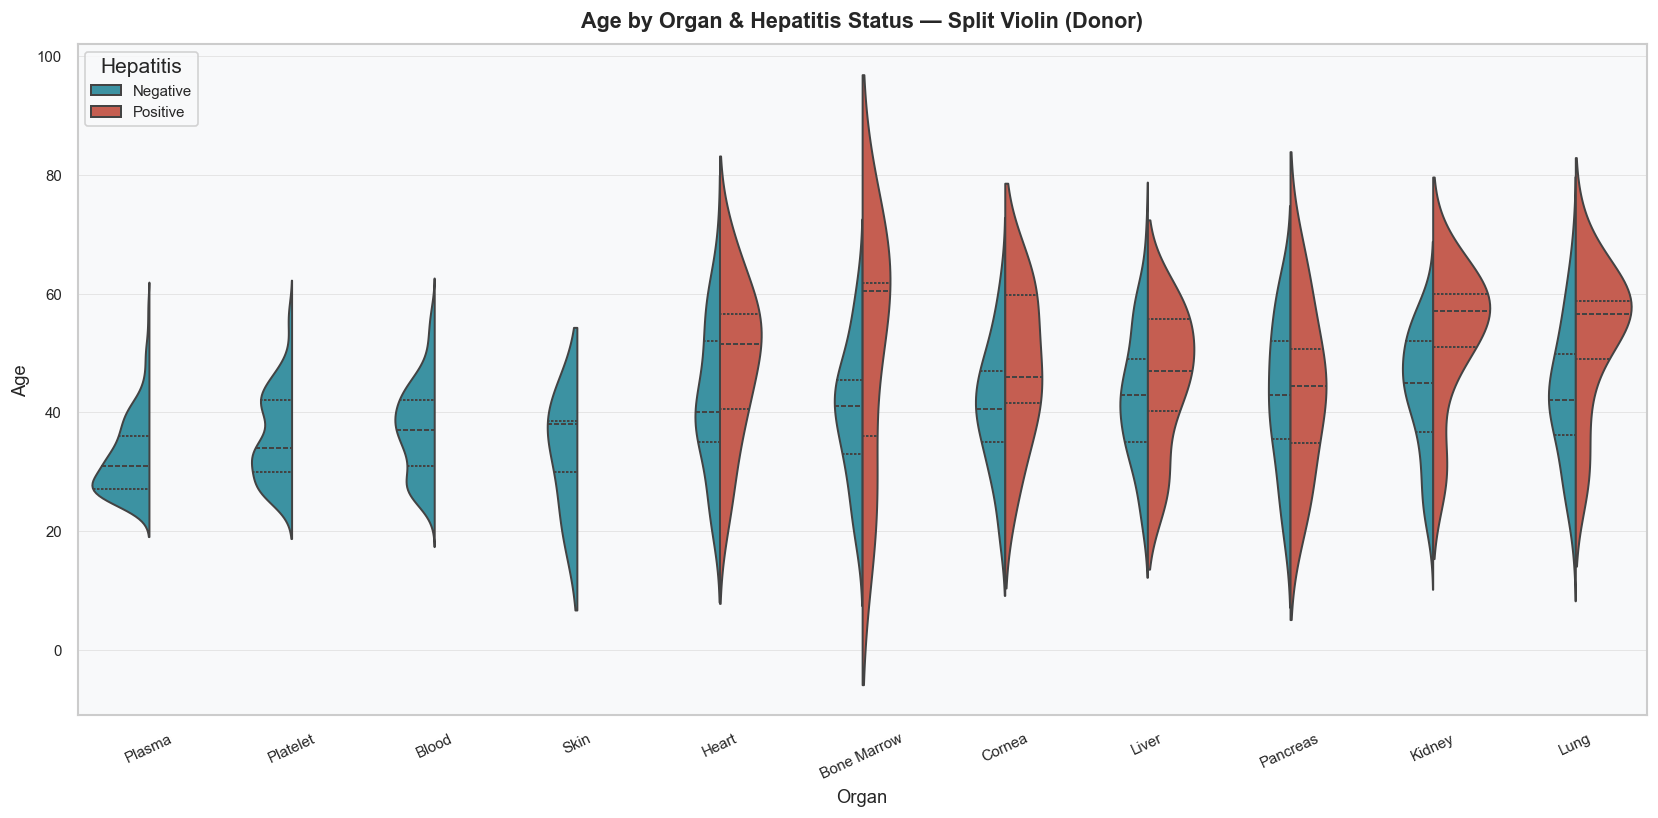

In [21]:
rows2 = []
for c in ORGAN_COLS:
    sub = df[df[c]==1][["age","hepatitis_status"]].copy()
    sub["Organ"] = c
    sub["Hepatitis"] = sub["hepatitis_status"].map({1:"Positive",0:"Negative"})
    rows2.append(sub)
olong = pd.concat(rows2, ignore_index=True)
ov_order = olong.groupby("Organ")["age"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(data=olong, x="Organ", y="age", hue="Hepatitis",
               palette={"Positive":C_RED,"Negative":C_TEAL},
               order=ov_order, split=True, inner="quart", linewidth=1.2, ax=ax)
ax.set_title("Age by Organ & Hepatitis Status — Split Violin (Donor)", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("Age"); ax.legend(title="Hepatitis", loc="upper left")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

### 3.3 Violin — Age by Cause of Death × Gender

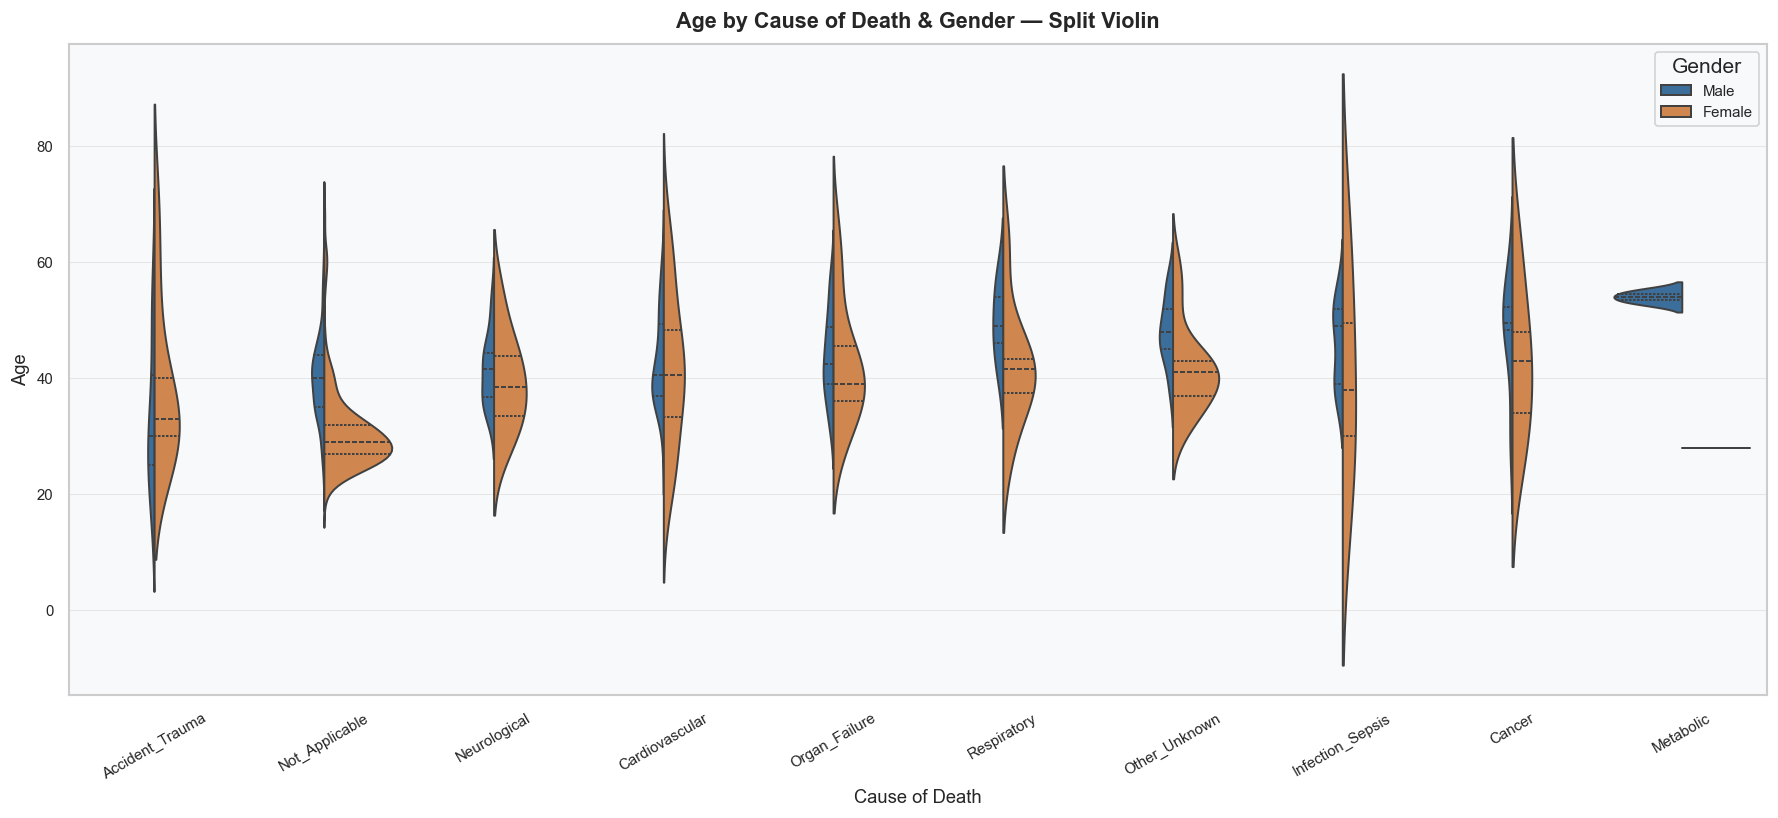

In [22]:
if "cause_category" in df.columns:
    stdf = df[["age","cause_category","gender_Male"]].copy()
    stdf["Gender"] = stdf["gender_Male"].map({1:"Male",0:"Female"})
    cause_order = stdf.groupby("cause_category")["age"].median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(15, 7))
    sns.violinplot(data=stdf, x="cause_category", y="age", hue="Gender",
                   order=cause_order, split=True, inner="quart",
                   palette=GENDER_PALETTE, linewidth=1.2, ax=ax)
    ax.set_title("Age by Cause of Death & Gender — Split Violin", fontsize=13, fontweight="bold")
    ax.set_xlabel("Cause of Death"); ax.set_ylabel("Age"); ax.legend(title="Gender")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.show()

### 3.4 Organ Donation Rate (%) by City — Heatmap

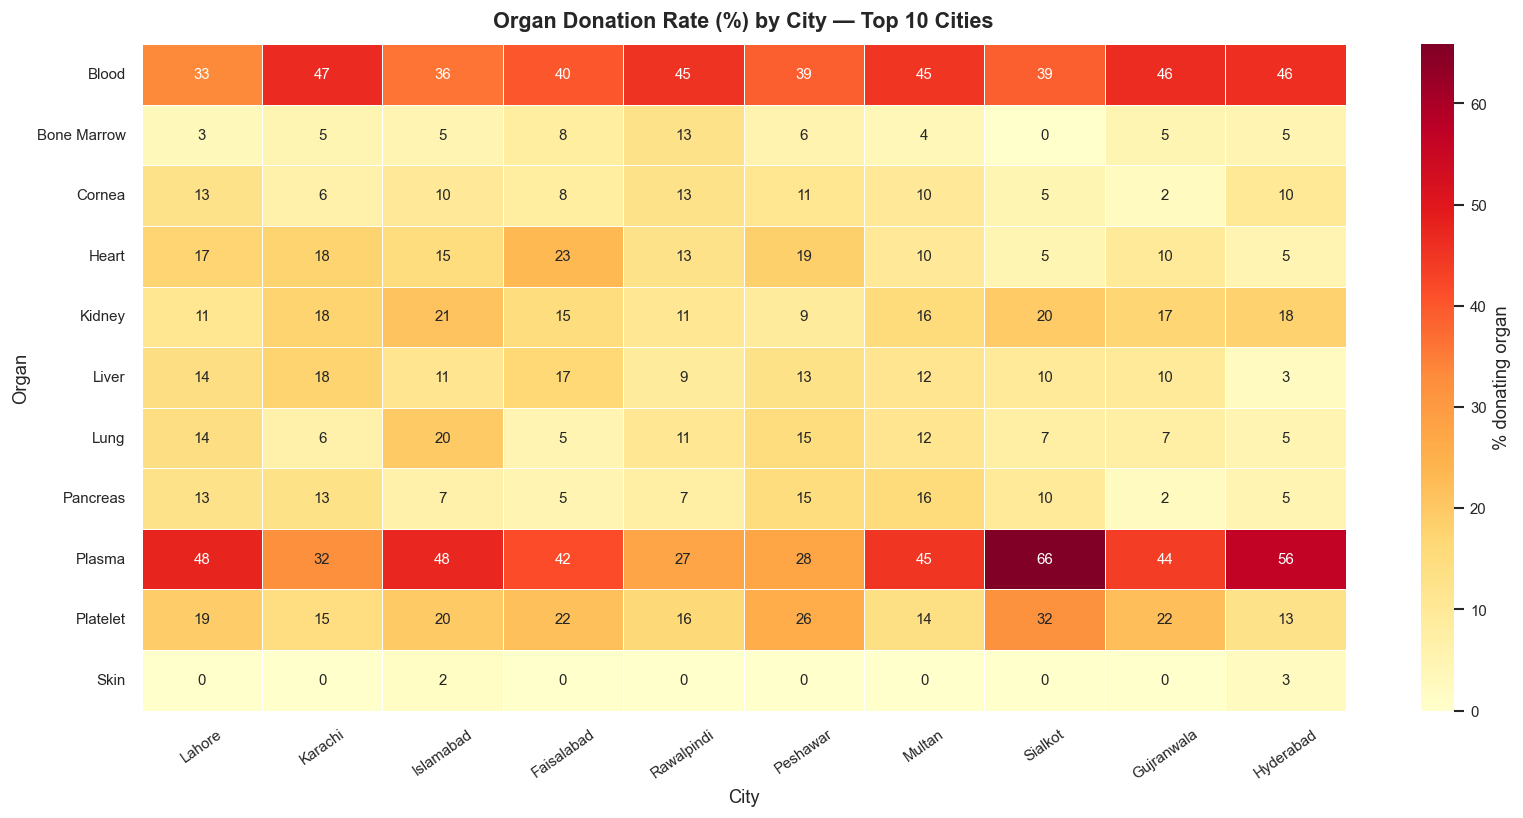

In [23]:
top_cities = city_series.head(10).index.tolist()
co = {}
for oc in ORGAN_COLS:
    co[oc] = {}
    for city in top_cities:
        cc = f"City_{city}"
        if cc in df.columns:
            co[oc][city] = df.loc[df[cc]==1,oc].mean()*100
co_df = pd.DataFrame(co).T
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(co_df, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", annot_kws={"size":9},
            cbar_kws={"label":"% donating organ"}, ax=ax)
ax.set_title("Organ Donation Rate (%) by City — Top 10 Cities", fontsize=13, fontweight="bold")
ax.set_xlabel("City"); ax.set_ylabel("Organ"); ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

### 3.5 Condition Prevalence (%) by Organ — Grouped Bar

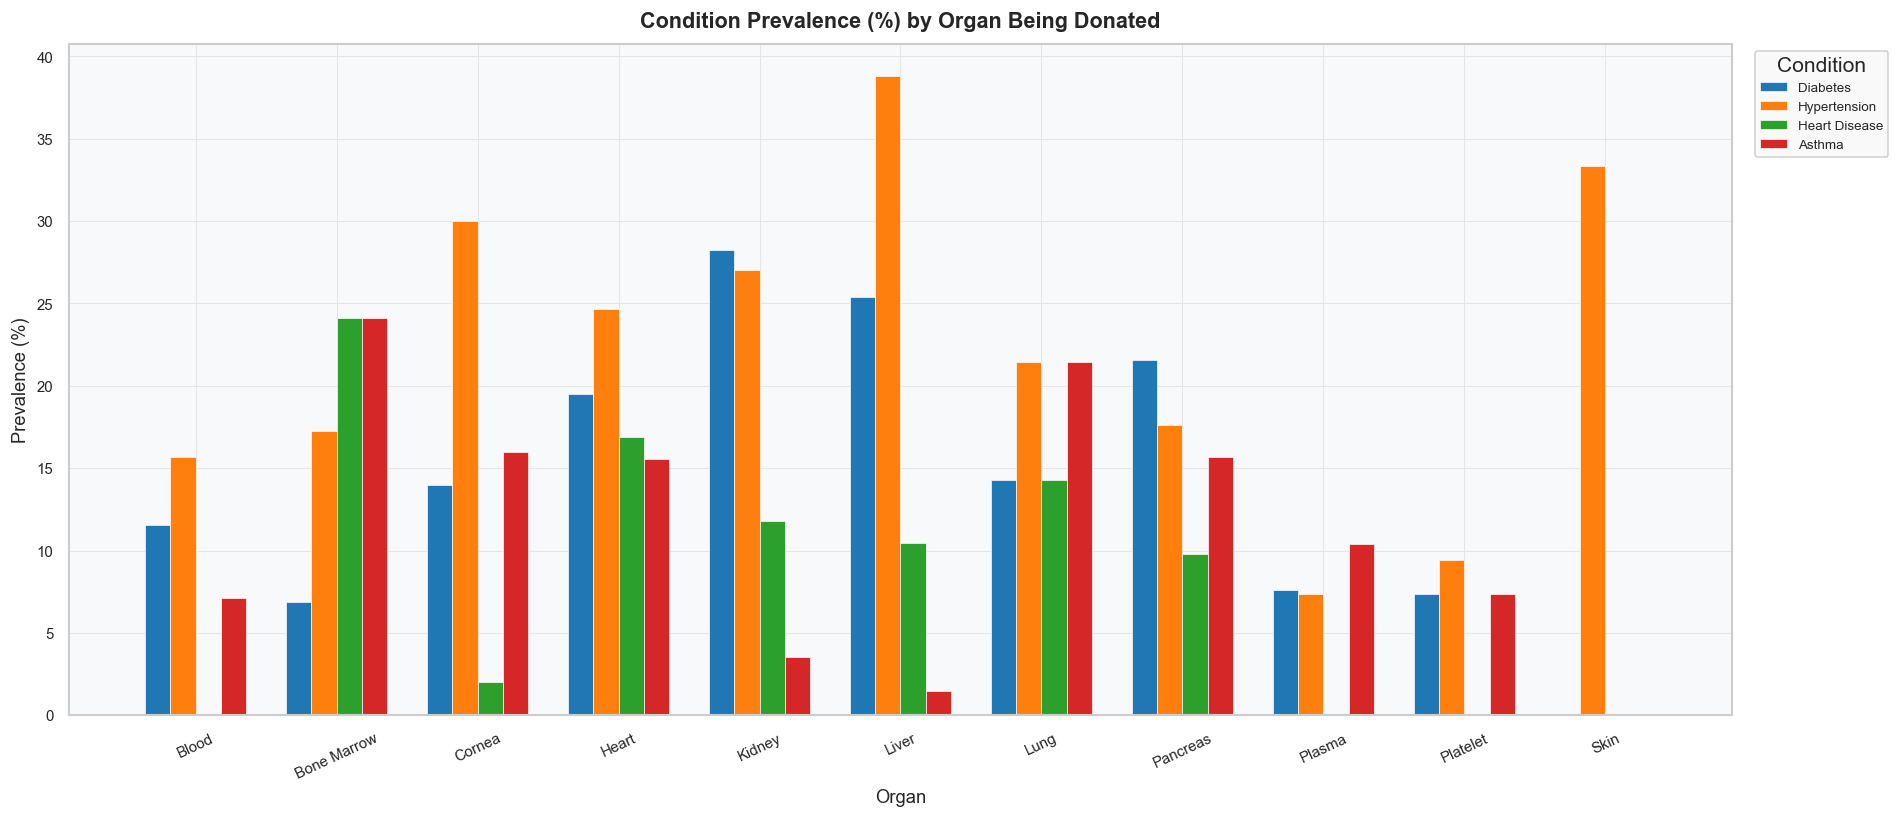

In [24]:
cnames = [c.replace("Condition_","").replace("_"," ") for c in COND_COLS]
x = np.arange(len(ORGAN_COLS)); w = 0.18
mat = pd.DataFrame(index=ORGAN_COLS, columns=cnames, dtype=float)
for oc in ORGAN_COLS:
    sub = df[df[oc]==1]
    for cc in COND_COLS:
        mat.loc[oc, cc.replace("Condition_","").replace("_"," ")] = sub[cc].mean()*100
fig, ax = plt.subplots(figsize=(16, 7))
for i,(cn,col) in enumerate(zip(cnames, sns.color_palette("tab10", len(cnames)))):
    ax.bar(x+(i-len(cnames)/2+0.5)*w, mat[cn], width=w, color=col, label=cn, edgecolor="white", linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(ORGAN_COLS, rotation=25)
ax.set_title("Condition Prevalence (%) by Organ Being Donated", fontsize=13, fontweight="bold")
ax.set_xlabel("Organ"); ax.set_ylabel("Prevalence (%)")
ax.legend(title="Condition", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

---
## 🚀 Section 4 — Advanced Analysis

### 4.1 Class Imbalance — Alive vs Deceased

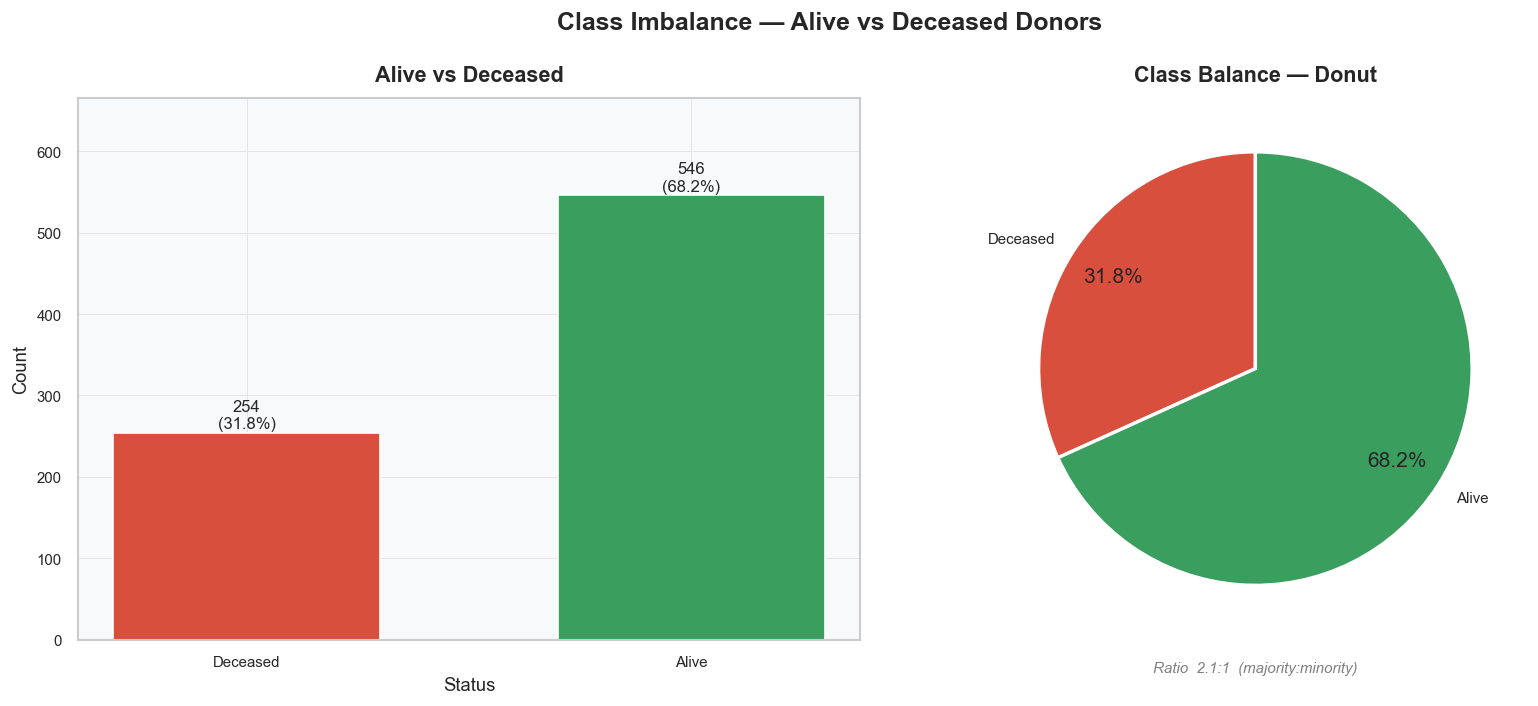

In [25]:
if "alive/deceased" in df.columns:
    sc = df["alive/deceased"].value_counts().sort_index()
    sl = ["Deceased" if i==0 else "Alive" for i in sc.index]
    sc_colors = [C_RED, C_GREEN]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    bars = axes[0].bar(sl, sc.values, color=sc_colors, edgecolor="white", width=0.6)
    for bar,val in zip(bars,sc.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                     f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
    axes[0].set_ylim(0, sc.max()*1.22); axes[0].set_title("Alive vs Deceased"); axes[0].set_xlabel("Status"); axes[0].set_ylabel("Count")
    axes[1].pie(sc.values, labels=sl, autopct="%1.1f%%", colors=sc_colors,
                startangle=90, pctdistance=0.78, wedgeprops=dict(edgecolor="white",linewidth=2))
    ir = sc.max()/sc.min() if sc.min()>0 else 0
    axes[1].text(0,-1.4,f"Ratio  {ir:.1f}:1  (majority:minority)",ha="center",fontsize=9,color="gray",style="italic")
    axes[1].set_title("Class Balance — Donut")
    fig.suptitle("Class Imbalance — Alive vs Deceased Donors", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()

### 4.2 Age KDE Overlay — by Organ Being Donated

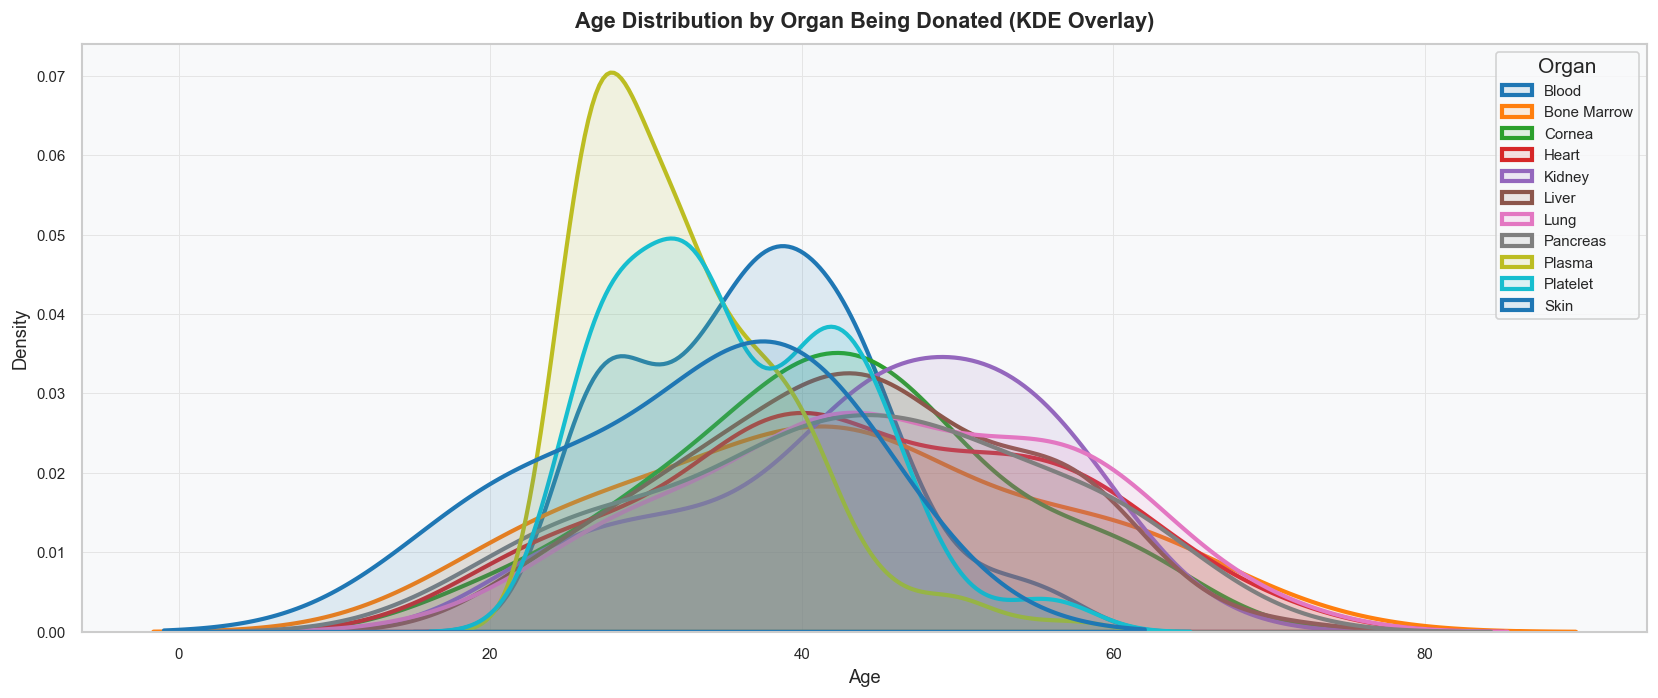

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))
for oc, col in zip(ORGAN_COLS, sns.color_palette("tab10", len(ORGAN_COLS))):
    sns.kdeplot(df.loc[df[oc]==1,"age"], ax=ax, label=oc,
                color=col, linewidth=2.5, fill=True, alpha=0.12)
ax.set_title("Age Distribution by Organ Being Donated (KDE Overlay)", fontsize=13, fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Density"); ax.legend(title="Organ")
plt.tight_layout(); plt.show()

### 4.3 Age KDE Overlay — by Cause of Death

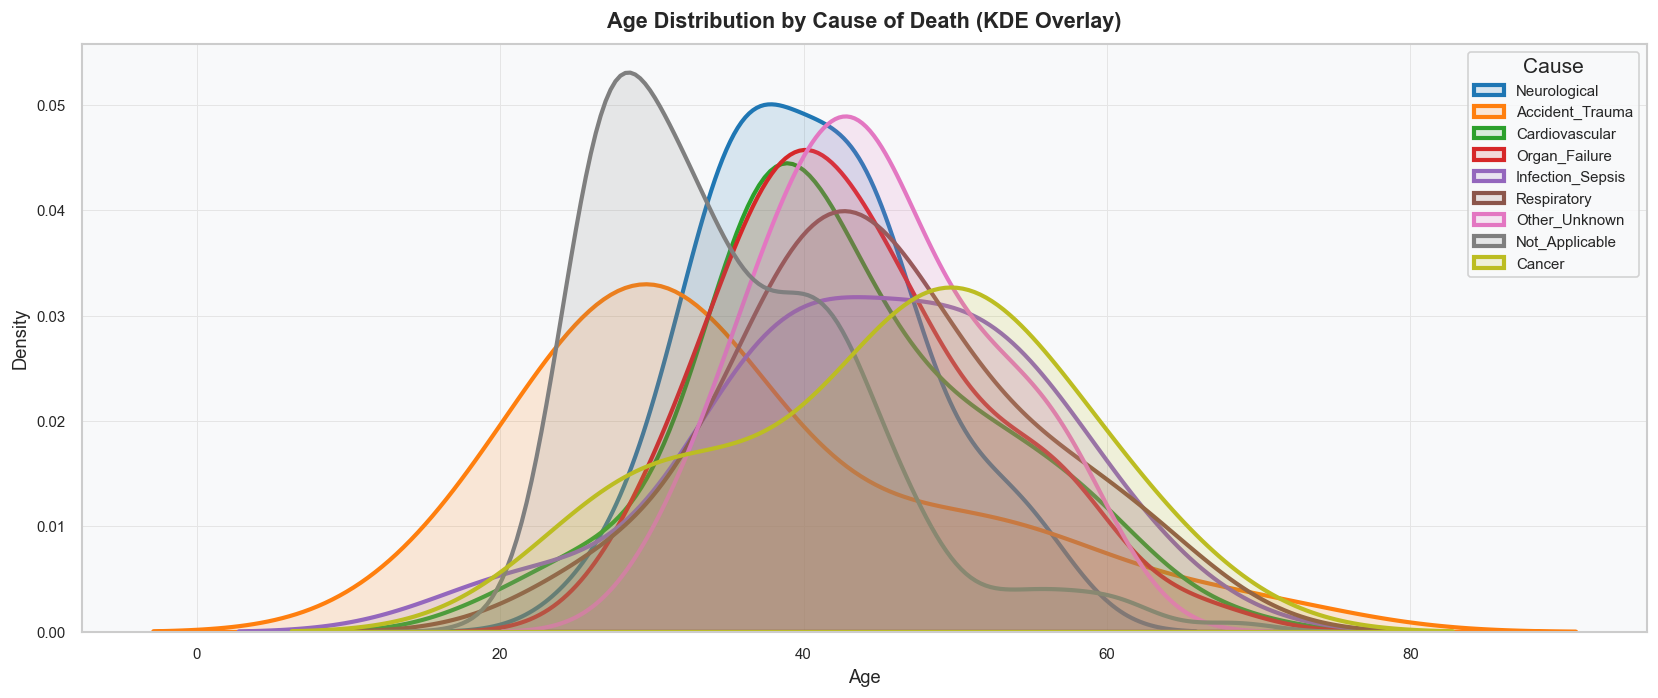

In [27]:
if "cause_category" in df.columns:
    causes = df["cause_category"].unique()
    palette = sns.color_palette("tab10", len(causes))
    fig, ax = plt.subplots(figsize=(14, 6))
    for cause, col in zip(causes, palette):
        sub = df.loc[df["cause_category"]==cause, "age"]
        if len(sub) > 5:
            sns.kdeplot(sub, ax=ax, label=cause, color=col, linewidth=2.5, fill=True, alpha=0.15)
    ax.set_title("Age Distribution by Cause of Death (KDE Overlay)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Age"); ax.set_ylabel("Density"); ax.legend(title="Cause")
    plt.tight_layout(); plt.show()

### 4.4 Harvest Time Distribution — Feasibility Analysis

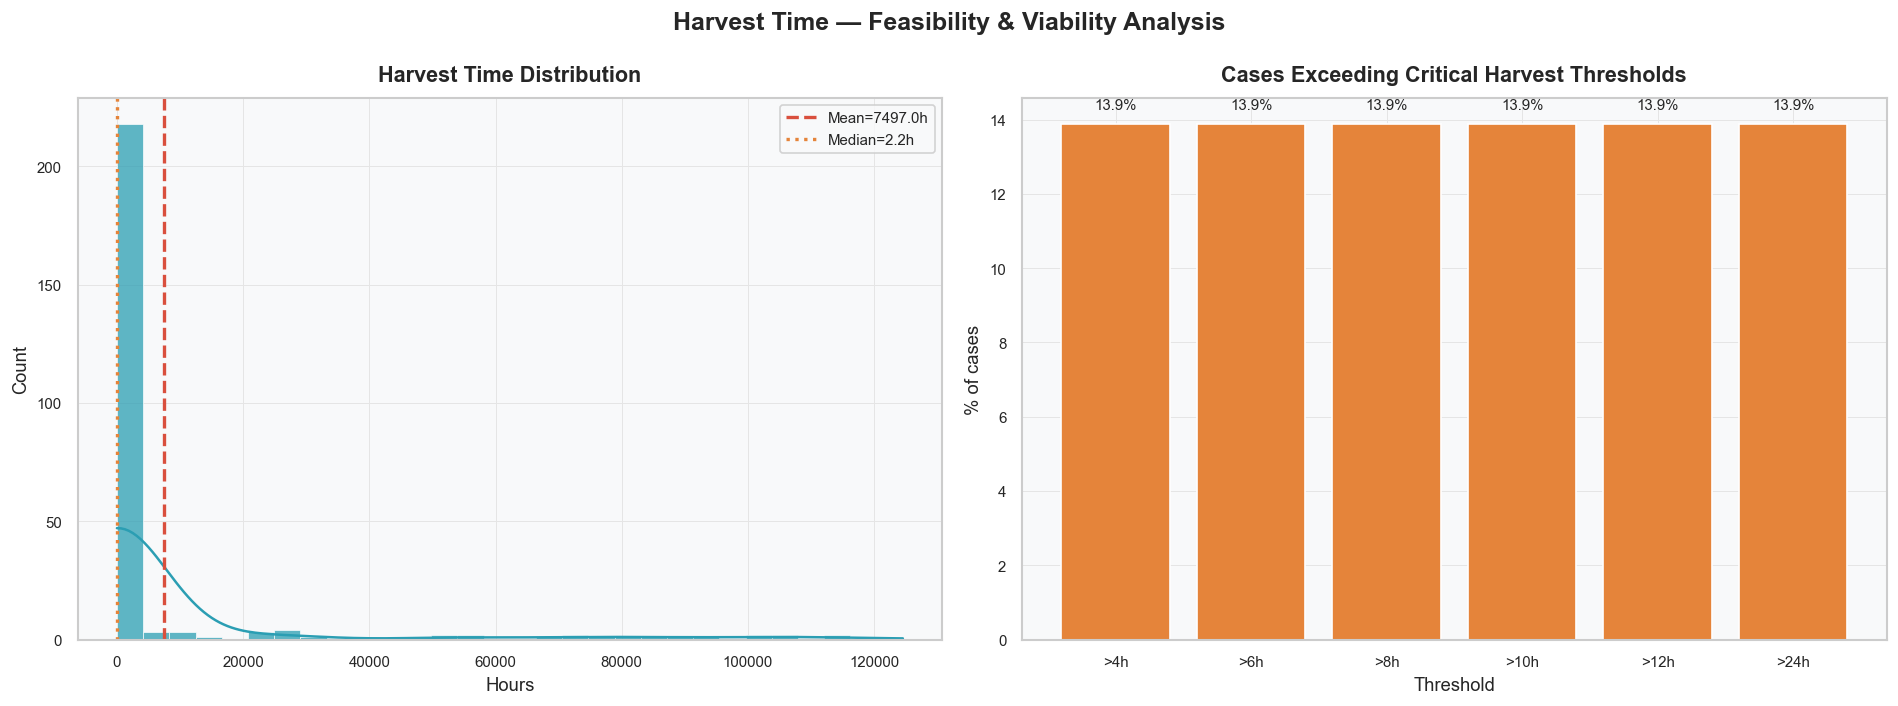

In [28]:
if "harvest_time_hours" in df.columns:
    valid = df[df["harvest_time_hours"] >= 0]["harvest_time_hours"]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.histplot(valid, kde=True, ax=axes[0], color=C_TEAL, bins=30,
                 edgecolor="white", linewidth=0.4, alpha=0.75)
    axes[0].axvline(valid.mean(),  color=C_RED,    linestyle="--", lw=2, label=f"Mean={valid.mean():.1f}h")
    axes[0].axvline(valid.median(),color=C_ORANGE, linestyle=":",  lw=2, label=f"Median={valid.median():.1f}h")
    axes[0].set_title("Harvest Time Distribution"); axes[0].set_xlabel("Hours"); axes[0].legend()
    thresholds = [4,6,8,10,12,24]
    pcts = [(valid > t).sum()/len(valid)*100 for t in thresholds]
    colors_t = ["#D94F3D" if p>20 else "#E5843A" if p>10 else "#3A9E5F" for p in pcts]
    axes[1].bar([f">{t}h" for t in thresholds], pcts, color=colors_t, edgecolor="white")
    for ax2b, pct in zip(axes[1].patches, pcts):
        axes[1].text(ax2b.get_x()+ax2b.get_width()/2, ax2b.get_height()+0.3,
                     f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    axes[1].set_title("Cases Exceeding Critical Harvest Thresholds")
    axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("% of cases")
    fig.suptitle("Harvest Time — Feasibility & Viability Analysis", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()

### 4.5 Conditions × Hepatitis Status — Co-occurrence Heatmap

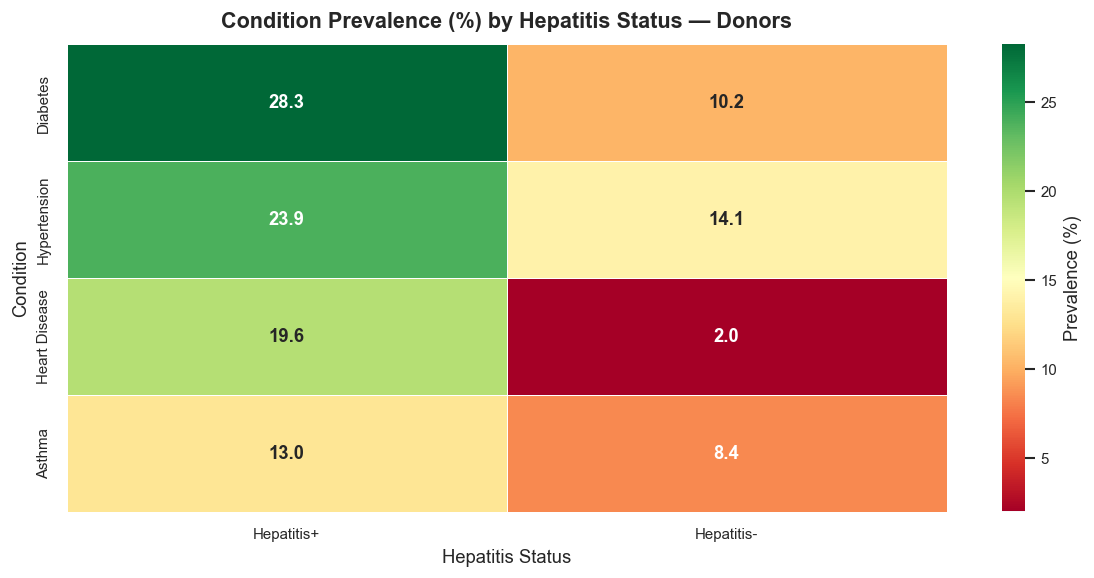

In [29]:
chep = pd.DataFrame({
    c.replace("Condition_","").replace("_"," "):{
        "Hepatitis+":df.loc[df["hepatitis_status"]==1,c].mean()*100,
        "Hepatitis-":df.loc[df["hepatitis_status"]==0,c].mean()*100}
    for c in COND_COLS}).T
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(chep, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=0.5, linecolor="white",
            annot_kws={"size":11,"weight":"bold"}, cbar_kws={"label":"Prevalence (%)"}, ax=ax)
ax.set_title("Condition Prevalence (%) by Hepatitis Status — Donors", fontsize=13, fontweight="bold")
ax.set_xlabel("Hepatitis Status"); ax.set_ylabel("Condition"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

### 4.6 EDA Summary Dashboard

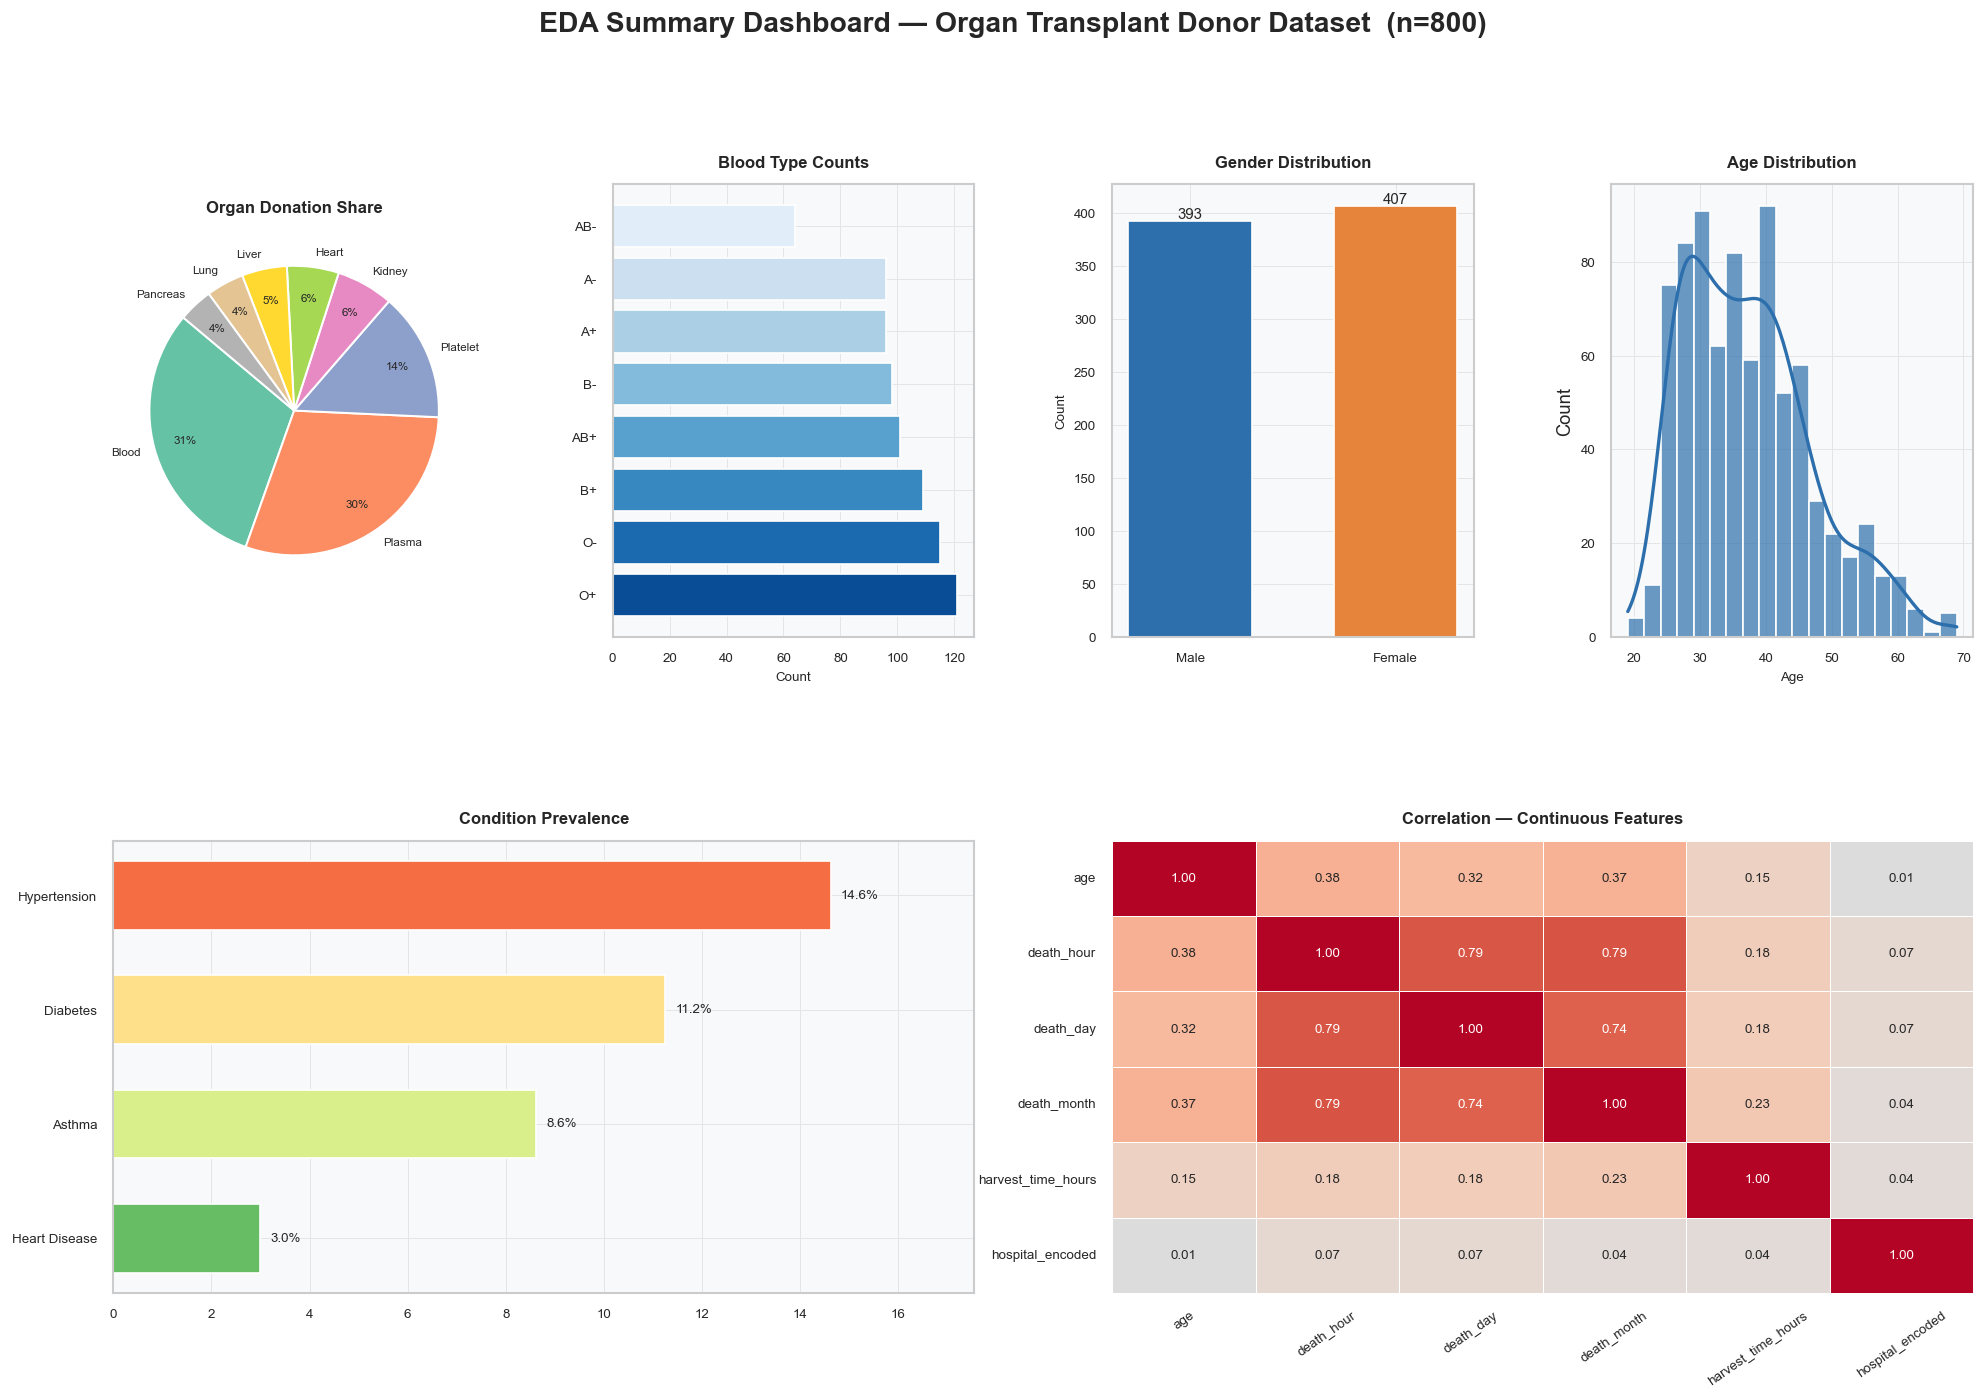


✅ All EDA visualizations complete!


In [30]:
organ_series  = pd.Series({c: df[c].sum() for c in ORGAN_COLS}).sort_values(ascending=False)
blood_series  = pd.Series({c.replace("blood_",""):df[c].sum() for c in BLOOD_COLS}).sort_values(ascending=False)
cond_pct2     = pd.Series({c.replace("Condition_","").replace("_"," "):df[c].mean()*100 for c in COND_COLS}).sort_values(ascending=True)

fig = plt.figure(figsize=(20, 12))
fig.suptitle("EDA Summary Dashboard — Organ Transplant Donor Dataset  (n=800)",
             fontsize=17, fontweight="bold", y=1.00)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

ax_a = fig.add_subplot(gs[0,0])
ax_a.pie(organ_series.values[:8], labels=organ_series.index[:8], autopct="%1.0f%%",
         colors=sns.color_palette("Set2",8), startangle=140, pctdistance=0.78,
         wedgeprops=dict(edgecolor="white",linewidth=1.2), textprops={"fontsize":7})
ax_a.set_title("Organ Donation Share", fontsize=10, fontweight="bold")

ax_b = fig.add_subplot(gs[0,1])
ax_b.barh(blood_series.index, blood_series.values,
          color=sns.color_palette("Blues_r",8), edgecolor="white")
ax_b.set_title("Blood Type Counts", fontsize=10, fontweight="bold")
ax_b.set_xlabel("Count",fontsize=8); ax_b.tick_params(labelsize=8)

ax_c = fig.add_subplot(gs[0,2])
g_vals = [df["gender_Male"].sum(), (df["gender_Male"]==0).sum()]
ax_c.bar(["Male","Female"], g_vals, color=[C_BLUE,C_ORANGE], edgecolor="white", width=0.6)
for bar,val in zip(ax_c.patches,g_vals):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f"{val}", ha="center", fontsize=9)
ax_c.set_title("Gender Distribution", fontsize=10, fontweight="bold")
ax_c.set_ylabel("Count",fontsize=8); ax_c.tick_params(labelsize=8)

ax_d = fig.add_subplot(gs[0,3])
sns.histplot(df["age"], kde=True, ax=ax_d, color=C_BLUE, bins=20, edgecolor="white", alpha=0.7,
             line_kws={"lw":2,"color":C_TEAL})
ax_d.set_title("Age Distribution", fontsize=10, fontweight="bold")
ax_d.set_xlabel("Age",fontsize=8); ax_d.tick_params(labelsize=8)

ax_e = fig.add_subplot(gs[1,0:2])
ax_e.barh(cond_pct2.index, cond_pct2.values, color=sns.color_palette("RdYlGn_r",len(cond_pct2)), edgecolor="white", height=0.6)
for i,val in enumerate(cond_pct2.values): ax_e.text(val+0.2, i, f"{val:.1f}%", va="center", fontsize=8)
ax_e.set_xlim(0, cond_pct2.max()*1.2); ax_e.set_title("Condition Prevalence", fontsize=10, fontweight="bold"); ax_e.tick_params(labelsize=8)

ax_f = fig.add_subplot(gs[1,2:4])
heat_c = [c for c in CORE_CONT if c in df.columns]
sns.heatmap(df[heat_c].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.4, linecolor="white", annot_kws={"size":8}, cbar=False, ax=ax_f)
ax_f.set_title("Correlation — Continuous Features", fontsize=10, fontweight="bold")
ax_f.tick_params(axis="x",rotation=35,labelsize=8); ax_f.tick_params(axis="y",rotation=0,labelsize=8)

plt.tight_layout(); plt.show()
print("\n✅ All EDA visualizations complete!")